```
O + CH4 <=> OH + CH3   1.020E+09   1.500   8600.00
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optimistix as optx
import time

from diffPLOG2TROE.parametrization import Arrhenius

# Enable float64 for better numerical precision
jax.config.update("jax_enable_x64", True)

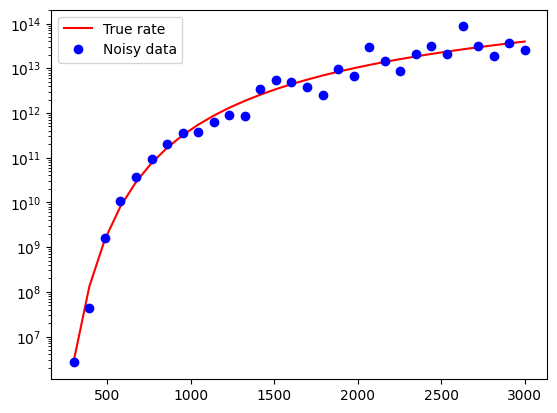

Loss on this step: 11148.299891364763, Step size: 1.0
Loss on this step: 3747.488405439588, Step size: 3.5
Loss on this step: 3747.3672644774338, Step size: 12.25
Loss on this step: 3746.953573514837, Step size: 42.875
Loss on this step: 3745.5061150533634, Step size: 150.0625
Loss on this step: 3740.44563881205, Step size: 525.21875
Loss on this step: 3722.802684882175, Step size: 1838.265625
Loss on this step: 3661.8841272773752, Step size: 6433.9296875
Loss on this step: 3458.447613321435, Step size: 22518.75390625
Loss on this step: 2850.693419592497, Step size: 78815.638671875
Loss on this step: 1553.1198465895554, Step size: 275854.7353515625
Loss on this step: 311.23702373555085, Step size: 965491.5737304688
Loss on this step: 14.323238087009184, Step size: 3379220.5080566406
Loss on this step: 3.6355778280058697, Step size: 11827271.778198242
Loss on this step: 3.5949255300562712, Step size: 41395451.22369385
Loss on this step: 3.594911762815185, Step size: 144884079.28292847
L

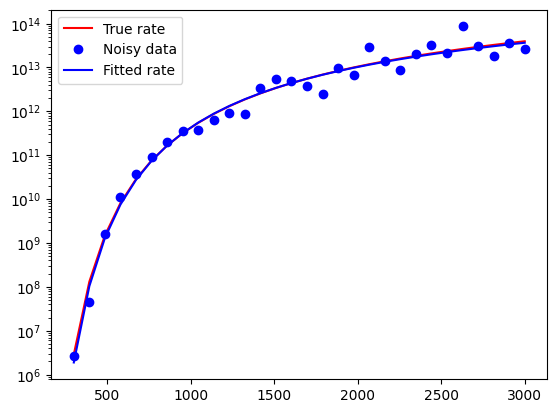

In [10]:
def residual_fn(params, args):
    T_data, k_data = args
    tmp_reaction = Arrhenius(
        name="O+CH4<=>OH+CH3",
        parameters={
            "A": params[0],
            "n": params[1],
            "Ea": params[2]
        }
    )
    k_pred = tmp_reaction.rate_constant(T_data)

    # Use log-space residuals for better numerical behavior
    # since rate constants can span many orders of magnitude
    return jnp.log(k_pred) - jnp.log(k_data)

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """
    Compute parameter uncertainties accounting for residual variance.
    
    Args:
        sol: Optimistix solution object
        residual_variance: Known variance of residuals, or None to estimate
    """
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
    else:
        # For FunctionLinearOperator, we need to evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            # Apply the Jacobian to this unit vector
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)  # degrees of freedom
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)  # fallback for overdetermined case
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular - parameters may be non-identifiable")
        return None, None, residual_variance

reaction = Arrhenius(name="O+CH4<=>OH+CH3", parameters={"A": 1.020E+09, "n": 1.500, "Ea": 8600.00})

T = jnp.linspace(300, 3000, 30)
k = reaction.rate_constant(T)

noise_level = 0.5
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=(T.shape[0],)) * noise_level
k_noisy = k * jnp.exp(noise)

plt.semilogy(T, k, "r-", label="True rate")
plt.semilogy(T, k_noisy, "bo", label="Noisy data")
plt.legend()
plt.show()

solver = optx.LevenbergMarquardt(rtol=1e-8, atol=1e-8, verbose=frozenset({"loss", "step_size"}))
# solver = optx.BFGS(rtol=1e-8, atol=1e-8, verbose=frozenset({"loss", "step_size"}))

# Solve the least squares problem
start_time = time.time()
sol = optx.least_squares(
    fn=residual_fn,
    solver=solver,
    y0=jnp.array([1e10,0.5, 50000.0]),
    args=(T, k_noisy)
)
end_time = time.time()
runtime = end_time - start_time

if sol.result == optx.RESULTS.successful:
    print(f"Optimization successful in {runtime:.4f} seconds")
    print(f"Number of iterations: {sol.stats['num_steps']}")
    print(f"Time per iteration: {runtime/sol.stats['num_steps']:.6f} seconds")
    
    std_errors, cov_matrix, residual_variance = compute_parameter_uncertainty_with_noise(sol)
    if std_errors is not None:
        print("\nParameter estimates:")
        for i, (param, std_err) in enumerate(zip(sol.value, std_errors)):
            print(f"  $\\Theta_{i}$: {param:.6f} ± {std_err:.6f}")
    
    reaction = Arrhenius(name="O+CH4<=>OH+CH3", parameters={"A": sol.value[0], "n": sol.value[1], "Ea": sol.value[2]})
    k_fitted = reaction.rate_constant(T)
    
    plt.semilogy(T, k, "r-", label="True rate")
    plt.semilogy(T, k_noisy, "bo", label="Noisy data")
    plt.semilogy(T, k_fitted, "b-", label="Fitted rate")
    plt.legend()
    plt.show()
else:
    print("✗ Optimization did not converge")
    print(f"Final result status: {sol.result}")
    print(f"Steps taken: {sol.stats['num_steps']}")
    print(f"Last parameter values: {sol.value}")

Loss on this step: 272.96139593629977, Step size: 1.0
Loss on this step: 3.048843529644661, Step size: 3.5
Loss on this step: 1.31981592029697, Step size: 12.25
Loss on this step: 0.548027066576809, Step size: 42.875
Loss on this step: 0.4853514047729681, Step size: 150.0625
Loss on this step: 0.48470659709697395, Step size: 525.21875
Loss on this step: 0.4845694943862418, Step size: 1838.265625
Loss on this step: 0.48409210212435655, Step size: 6433.9296875
Loss on this step: 0.4824279221752479, Step size: 22518.75390625
Loss on this step: 0.4766842787761203, Step size: 78815.638671875
Loss on this step: 0.45753234902239537, Step size: 275854.7353515625
Loss on this step: 0.4005964964072901, Step size: 965491.5737304688
Loss on this step: 0.28068998584337307, Step size: 3379220.5080566406
Loss on this step: 0.1691328938733061, Step size: 11827271.778198242
Loss on this step: 0.14357543884712543, Step size: 41395451.22369385
Loss on this step: 0.14270379589193213, Step size: 144884079.

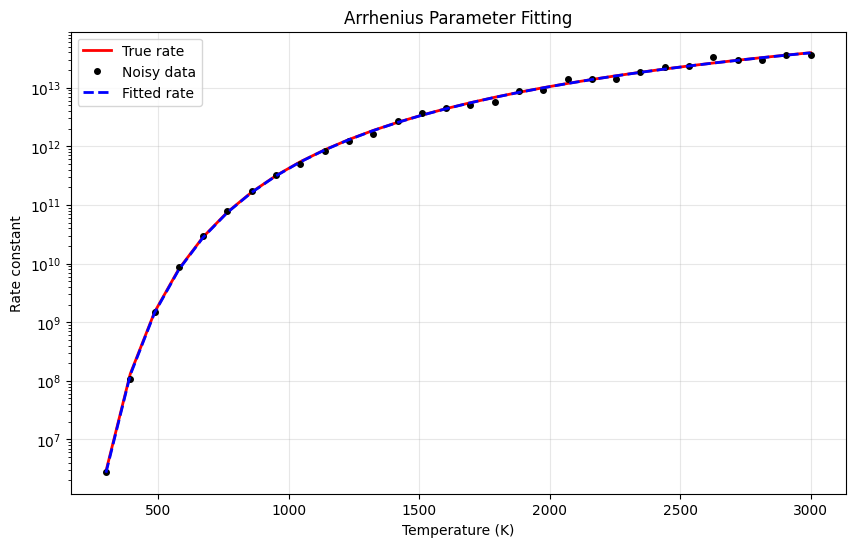

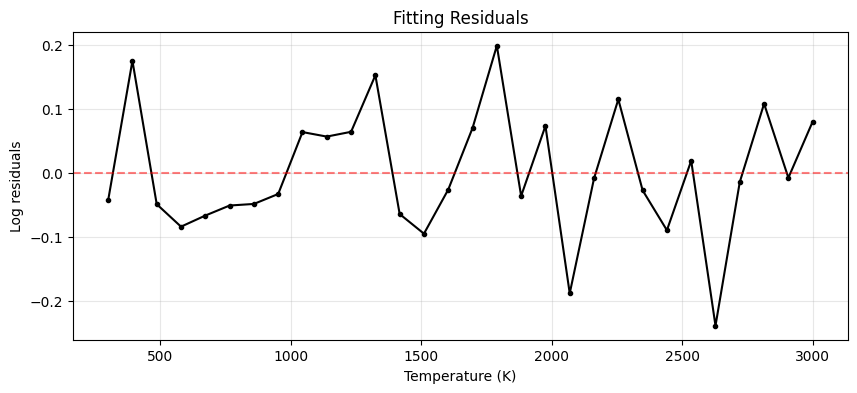

In [14]:
import jax.numpy as jnp
import jax
import optimistix as optx
import matplotlib.pyplot as plt
import time

def residual_fn_scaled(params, args):
    """Residual function with scaled parameters for better numerical behavior."""
    T_data, k_data = args
    tmp_reaction = Arrhenius(
        name="O+CH4<=>OH+CH3",
        parameters={
            "A": jnp.exp(params[0]),  # Use exp(log(A)) for better scaling
            "n": params[1],
            "Ea": params[2]
        }
    )
    k_pred = tmp_reaction.rate_constant(T_data)
    return jnp.log(k_pred) - jnp.log(k_data)

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """Compute parameter uncertainties accounting for residual variance."""
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
        print("Dense jacobian")
    else:
        # For FunctionLinearOperator, evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular")
        return None, None, residual_variance

def print_results_scaled(sol, runtime, true_params):
    """Print results with proper handling of scaled parameters."""
    if sol.result == optx.RESULTS.successful:
        print(f"✓ Optimization successful in {runtime:.4f} seconds")
        print(f"Number of iterations: {sol.stats['num_steps']}")
        print(f"Time per iteration: {runtime/sol.stats['num_steps']:.6f} seconds")
        
        # Convert back from log-space
        A_fitted = jnp.exp(sol.value[0])
        n_fitted = sol.value[1]
        Ea_fitted = sol.value[2]
        
        print(f"\nFitted vs True parameters:")
        print(f"  A:  {A_fitted:.3e}  (true: {true_params[0]:.3e})")
        print(f"  n:  {n_fitted:.3f}  (true: {true_params[1]:.3f})")
        print(f"  Ea: {Ea_fitted:.3e} (true: {true_params[2]:.3e})")
        
        # Compute uncertainties
        std_errors, cov_matrix, residual_variance = compute_parameter_uncertainty_with_noise(sol)
        
        if std_errors is not None:
            # For log(A), convert uncertainty back to A using delta method
            A_std = A_fitted * std_errors[0]
            
            print(f"\nParameter uncertainties:")
            print(f"  A:  {A_fitted:.3e} ± {A_std:.3e}")
            print(f"  n:  {n_fitted:.3f} ± {std_errors[1]:.3f}")
            print(f"  Ea: {Ea_fitted:.3e} ± {std_errors[2]:.3e}")
            
            print(f"\nResidual standard deviation: {jnp.sqrt(residual_variance):.4f}")
            
            # Calculate relative errors
            rel_error_A = abs(A_fitted - true_params[0]) / true_params[0] * 100
            rel_error_n = abs(n_fitted - true_params[1]) / true_params[1] * 100
            rel_error_Ea = abs(Ea_fitted - true_params[2]) / true_params[2] * 100
            
            print(f"\nRelative errors:")
            print(f"  A:  {rel_error_A:.1f}%")
            print(f"  n:  {rel_error_n:.1f}%")
            print(f"  Ea: {rel_error_Ea:.1f}%")
        
        return A_fitted, n_fitted, Ea_fitted
    else:
        print("✗ Optimization failed")
        print(f"Status: {sol.result}")
        return None, None, None

# Generate synthetic data
reaction_true = Arrhenius(
    name="O+CH4<=>OH+CH3", 
    parameters={"A": 1.020e9, "n": 1.500, "Ea": 8600.0}
)
T = jnp.linspace(300, 3000, 30)
k_true = reaction_true.rate_constant(T)

# Add noise
noise_level = 0.1  # Reduced noise for better fitting
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=T.shape) * noise_level
k_noisy = k_true * jnp.exp(noise)

# Set up optimization
solver = optx.LevenbergMarquardt(
    rtol=1e-10, 
    atol=1e-10, 
    verbose=frozenset({"loss", "step_size"})
)

# Better initial guess (in log-space for A)
initial_guess = jnp.array([jnp.log(1e9), 1.0, 10000.0])

# Run optimization
start_time = time.time()
sol = optx.least_squares(
    fn=residual_fn_scaled,
    solver=solver,
    y0=initial_guess,
    args=(T, k_noisy)  # Use noisy data
)
runtime = time.time() - start_time

# Print results
true_params = [1.020e9, 1.500, 8600.0]
A_fit, n_fit, Ea_fit = print_results_scaled(sol, runtime, true_params)

# Plot results
if A_fit is not None:
    reaction_fitted = Arrhenius(
        name="O+CH4<=>OH+CH3", 
        parameters={"A": A_fit, "n": n_fit, "Ea": Ea_fit}
    )
    k_fitted = reaction_fitted.rate_constant(T)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(T, k_true, "r-", linewidth=2, label="True rate")
    plt.semilogy(T, k_noisy, "ko", markersize=4, label="Noisy data")
    plt.semilogy(T, k_fitted, "b--", linewidth=2, label="Fitted rate")
    plt.xlabel("Temperature (K)")
    plt.ylabel("Rate constant")
    plt.title("Arrhenius Parameter Fitting")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot residuals
    plt.figure(figsize=(10, 4))
    residuals = jnp.log(k_fitted) - jnp.log(k_noisy)
    plt.plot(T, residuals, "ko-", markersize=3)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.xlabel("Temperature (K)")
    plt.ylabel("Log residuals")
    plt.title("Fitting Residuals")
    plt.grid(True, alpha=0.3)
    plt.show()

Loss on this step: 272.96139593629977, Step size: 1.0
Loss on this step: 3.048843529644661, Step size: 3.5
Loss on this step: 1.31981592029697, Step size: 12.25
Loss on this step: 0.548027066576809, Step size: 42.875
Loss on this step: 0.4853514047729681, Step size: 150.0625
Loss on this step: 0.48470659709697395, Step size: 525.21875
Loss on this step: 0.4845694943862418, Step size: 1838.265625
Loss on this step: 0.48409210212435655, Step size: 6433.9296875
Loss on this step: 0.4824279221752479, Step size: 22518.75390625
Loss on this step: 0.4766842787761203, Step size: 78815.638671875
Loss on this step: 0.45753234902239537, Step size: 275854.7353515625
Loss on this step: 0.4005964964072901, Step size: 965491.5737304688
Loss on this step: 0.28068998584337307, Step size: 3379220.5080566406
Loss on this step: 0.1691328938733061, Step size: 11827271.778198242
Loss on this step: 0.14357543884712543, Step size: 41395451.22369385
Loss on this step: 0.14270379589193213, Step size: 144884079.

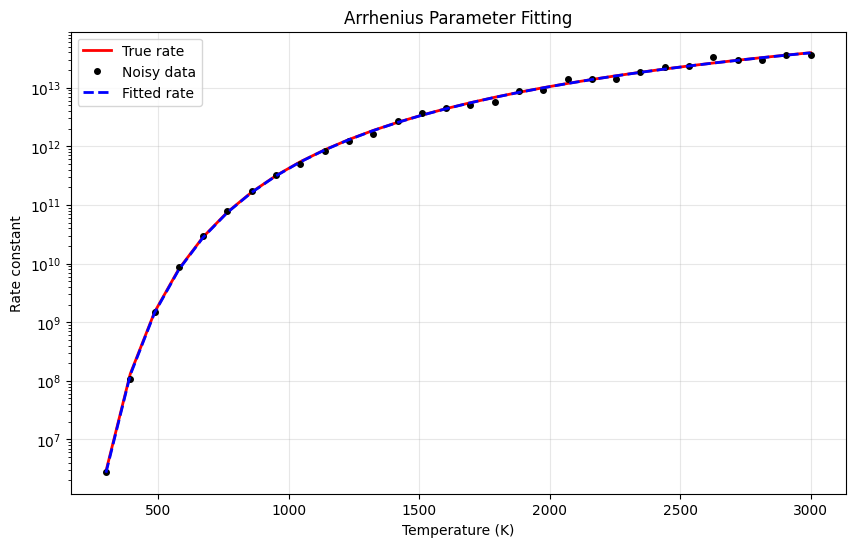

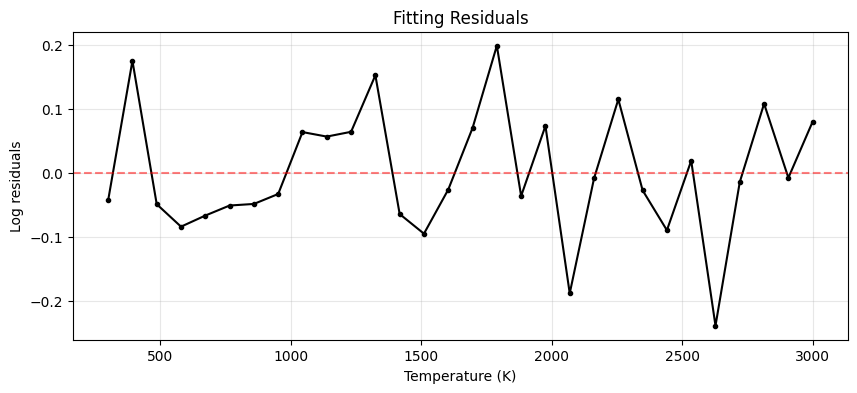

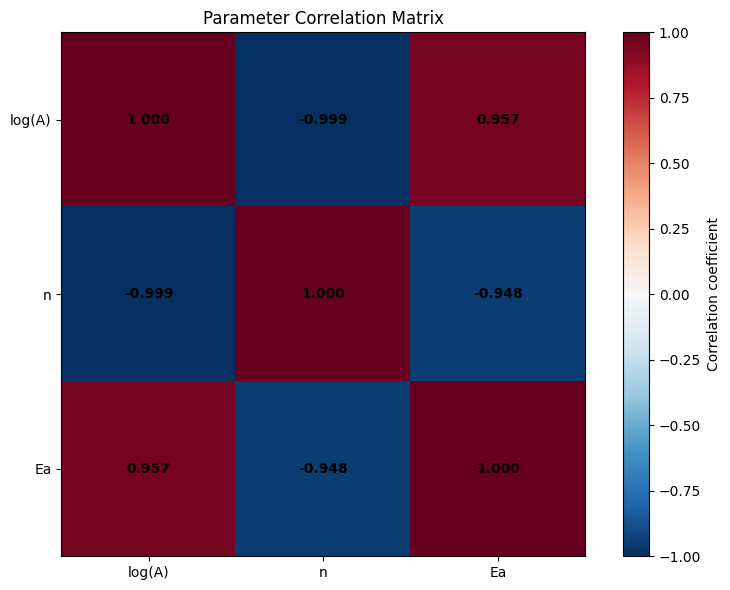

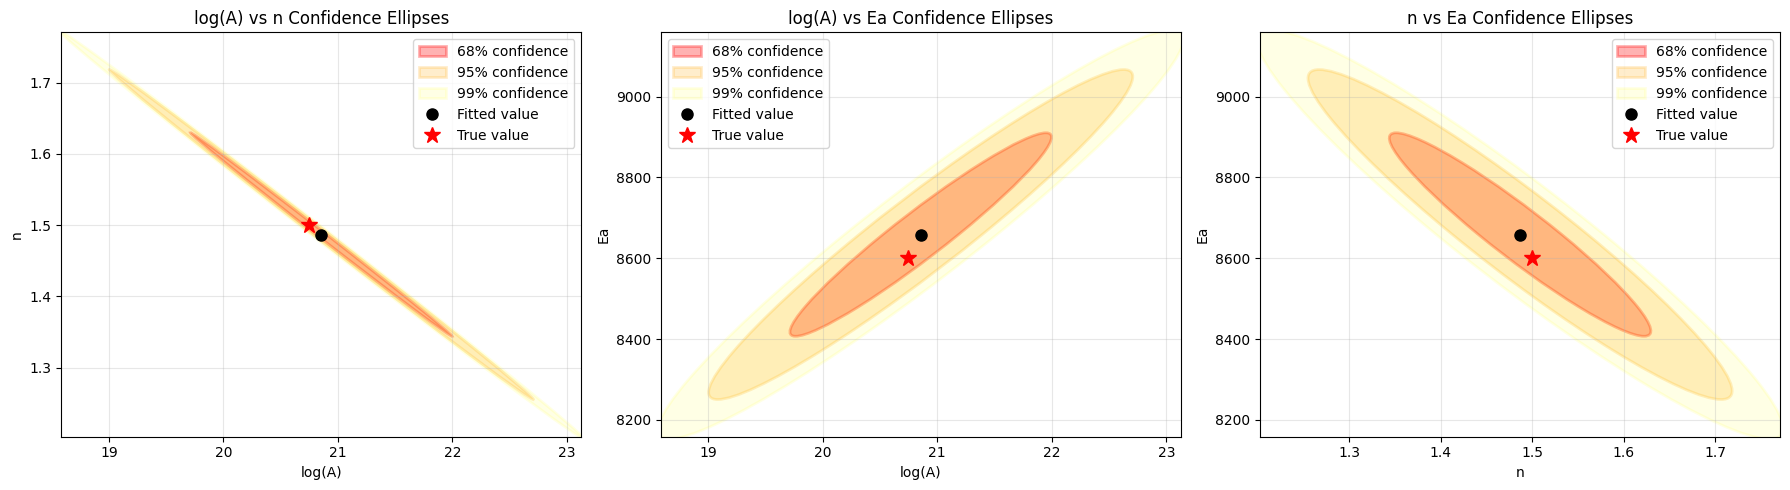

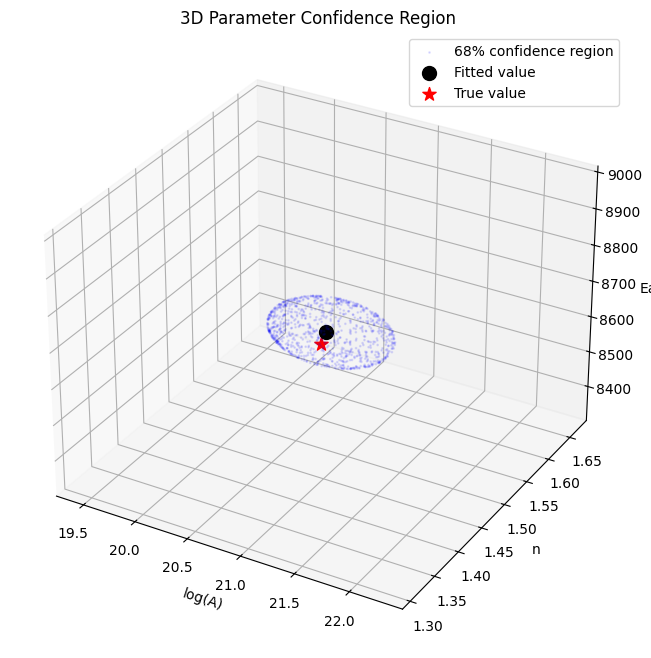

In [13]:
import jax.numpy as jnp
import jax
import optimistix as optx
import matplotlib.pyplot as plt
import time

def residual_fn_scaled(params, args):
    """Residual function with scaled parameters for better numerical behavior."""
    T_data, k_data = args
    tmp_reaction = Arrhenius(
        name="O+CH4<=>OH+CH3",
        parameters={
            "A": jnp.exp(params[0]),  # Use exp(log(A)) for better scaling
            "n": params[1],
            "Ea": params[2]
        }
    )
    k_pred = tmp_reaction.rate_constant(T_data)
    return jnp.log(k_pred) - jnp.log(k_data)

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """Compute parameter uncertainties accounting for residual variance."""
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
    else:
        # For FunctionLinearOperator, evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular")
        return None, None, residual_variance

def print_results_scaled(sol, runtime, true_params):
    """Print results with proper handling of scaled parameters."""
    if sol.result == optx.RESULTS.successful:
        print(f"✓ Optimization successful in {runtime:.4f} seconds")
        print(f"Number of iterations: {sol.stats['num_steps']}")
        print(f"Time per iteration: {runtime/sol.stats['num_steps']:.6f} seconds")
        
        # Convert back from log-space
        A_fitted = jnp.exp(sol.value[0])
        n_fitted = sol.value[1]
        Ea_fitted = sol.value[2]
        
        print(f"\nFitted vs True parameters:")
        print(f"  A:  {A_fitted:.3e} (true: {true_params[0]:.3e})")
        print(f"  n:  {n_fitted:.3f} (true: {true_params[1]:.3f})")
        print(f"  Ea: {Ea_fitted:.1f} K (true: {true_params[2]:.1f} K)")
        
        # Compute uncertainties
        std_errors, cov_matrix, residual_variance = compute_parameter_uncertainty_with_noise(sol)
        
        if std_errors is not None:
            # For log(A), convert uncertainty back to A using delta method
            A_std = A_fitted * std_errors[0]
            
            print(f"\nParameter uncertainties:")
            print(f"  A:  {A_fitted:.3e} ± {A_std:.3e}")
            print(f"  n:  {n_fitted:.3f} ± {std_errors[1]:.3f}")
            print(f"  Ea: {Ea_fitted:.1f} ± {std_errors[2]:.1f} K")
            
            print(f"\nResidual standard deviation: {jnp.sqrt(residual_variance):.4f}")
            
            # Calculate relative errors
            rel_error_A = abs(A_fitted - true_params[0]) / true_params[0] * 100
            rel_error_n = abs(n_fitted - true_params[1]) / true_params[1] * 100
            rel_error_Ea = abs(Ea_fitted - true_params[2]) / true_params[2] * 100
            
            print(f"\nRelative errors:")
            print(f"  A:  {rel_error_A:.1f}%")
            print(f"  n:  {rel_error_n:.1f}%")
            print(f"  Ea: {rel_error_Ea:.1f}%")
        
        return A_fitted, n_fitted, Ea_fitted
    else:
        print("✗ Optimization failed")
        print(f"Status: {sol.result}")
        return None, None, None

# Generate synthetic data
reaction_true = Arrhenius(
    name="O+CH4<=>OH+CH3", 
    parameters={"A": 1.020e9, "n": 1.500, "Ea": 8600.0}
)
T = jnp.linspace(300, 3000, 30)
k_true = reaction_true.rate_constant(T)

# Add noise
noise_level = 0.1  # Reduced noise for better fitting
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=T.shape) * noise_level
k_noisy = k_true * jnp.exp(noise)

# Set up optimization
solver = optx.LevenbergMarquardt(
    rtol=1e-10, 
    atol=1e-10, 
    verbose=frozenset({"loss", "step_size"})
)

# Better initial guess (in log-space for A)
initial_guess = jnp.array([jnp.log(1e9), 1.0, 10000.0])

# Run optimization
start_time = time.time()
sol = optx.least_squares(
    fn=residual_fn_scaled,
    solver=solver,
    y0=initial_guess,
    args=(T, k_noisy)  # Use noisy data
)
runtime = time.time() - start_time

# Print results
true_params = [1.020e9, 1.500, 8600.0]
A_fit, n_fit, Ea_fit = print_results_scaled(sol, runtime, true_params)

# Plot results
if A_fit is not None:
    reaction_fitted = Arrhenius(
        name="O+CH4<=>OH+CH3", 
        parameters={"A": A_fit, "n": n_fit, "Ea": Ea_fit}
    )
    k_fitted = reaction_fitted.rate_constant(T)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(T, k_true, "r-", linewidth=2, label="True rate")
    plt.semilogy(T, k_noisy, "ko", markersize=4, label="Noisy data")
    plt.semilogy(T, k_fitted, "b--", linewidth=2, label="Fitted rate")
    plt.xlabel("Temperature (K)")
    plt.ylabel("Rate constant")
    plt.title("Arrhenius Parameter Fitting")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot residuals
    plt.figure(figsize=(10, 4))
    residuals = jnp.log(k_fitted) - jnp.log(k_noisy)
    plt.plot(T, residuals, "ko-", markersize=3)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.xlabel("Temperature (K)")
    plt.ylabel("Log residuals")
    plt.title("Fitting Residuals")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot correlation matrix as heatmap
    std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol)
    if cov_matrix is not None:
        std_matrix = jnp.outer(std_errors, std_errors)
        corr_matrix = cov_matrix / std_matrix
        
        plt.figure(figsize=(8, 6))
        im = plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
        plt.colorbar(im, label='Correlation coefficient')
        
        # Add text annotations
        param_labels = ['log(A)', 'n', 'Ea']
        for i in range(3):
            for j in range(3):
                text = plt.text(j, i, f'{corr_matrix[i, j]:.3f}',
                               ha="center", va="center", color="black", fontweight='bold')
        
        plt.xticks(range(3), param_labels)
        plt.yticks(range(3), param_labels)
        plt.title('Parameter Correlation Matrix')
        plt.tight_layout()
        plt.show()
        
        # Plot confidence ellipses for parameter pairs
        from matplotlib.patches import Ellipse
        import numpy as np
        from scipy.stats import chi2
        
        # Convert to regular numpy arrays for matplotlib
        fitted_params = np.array([sol.value[0], sol.value[1], sol.value[2]])  # [log(A), n, Ea]
        cov_np = np.array(cov_matrix)
        
        # Confidence levels
        confidence_levels = [0.68, 0.95, 0.99]  # 1σ, 2σ, 3σ approximately
        colors = ['red', 'orange', 'yellow']
        alphas = [0.3, 0.2, 0.1]
        
        # Parameter pairs to plot
        param_pairs = [(0, 1, 'log(A)', 'n'), (0, 2, 'log(A)', 'Ea'), (1, 2, 'n', 'Ea')]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for idx, (i, j, xlabel, ylabel) in enumerate(param_pairs):
            ax = axes[idx]
            
            # Extract 2x2 covariance submatrix for this parameter pair
            cov_2d = cov_np[np.ix_([i, j], [i, j])]
            
            # Eigenvalues and eigenvectors for ellipse orientation
            eigenvals, eigenvecs = np.linalg.eigh(cov_2d)
            
            # Sort by eigenvalue
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            
            # Angle of first eigenvector
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            
            # Plot confidence ellipses
            for conf_level, color, alpha in zip(confidence_levels, colors, alphas):
                # Chi-square critical value for 2 DOF
                chi2_val = chi2.ppf(conf_level, df=2)
                
                # Ellipse semi-axes lengths
                width = 2 * np.sqrt(chi2_val * eigenvals[0])
                height = 2 * np.sqrt(chi2_val * eigenvals[1])
                
                # Create ellipse
                ellipse = Ellipse(
                    xy=(fitted_params[i], fitted_params[j]),
                    width=width,
                    height=height,
                    angle=angle,
                    facecolor=color,
                    alpha=alpha,
                    edgecolor=color,
                    linewidth=2,
                    label=f'{conf_level*100:.0f}% confidence'
                )
                ax.add_patch(ellipse)
            
            # Plot the fitted point
            ax.plot(fitted_params[i], fitted_params[j], 'ko', markersize=8, 
                   label='Fitted value', zorder=10)
            
            # Plot true value if available
            true_values = [np.log(1.020e9), 1.500, 8600.0]
            ax.plot(true_values[i], true_values[j], 'r*', markersize=12, 
                   label='True value', zorder=10)
            
            # Set labels and title
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{xlabel} vs {ylabel} Confidence Ellipses')
            ax.grid(True, alpha=0.3)
            ax.legend()
            
            # Set axis limits to show ellipses nicely
            center_x, center_y = fitted_params[i], fitted_params[j]
            max_std_x = 3 * np.sqrt(cov_2d[0, 0])
            max_std_y = 3 * np.sqrt(cov_2d[1, 1])
            
            ax.set_xlim(center_x - max_std_x, center_x + max_std_x)
            ax.set_ylim(center_y - max_std_y, center_y + max_std_y)
        
        plt.tight_layout()
        plt.show()
        
        # Also create a 3D visualization of the confidence region
        from mpl_toolkits.mplot3d import Axes3D
        
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Generate points on confidence ellipsoid surface (1σ level)
        chi2_val_3d = chi2.ppf(0.68, df=3)  # 3 DOF for 3 parameters
        
        # Sample points on unit sphere
        n_points = 1000
        phi = np.random.uniform(0, 2*np.pi, n_points)
        costheta = np.random.uniform(-1, 1, n_points)
        theta = np.arccos(costheta)
        
        x_sphere = np.sin(theta) * np.cos(phi)
        y_sphere = np.sin(theta) * np.sin(phi)
        z_sphere = np.cos(theta)
        
        sphere_points = np.column_stack([x_sphere, y_sphere, z_sphere])
        
        # Transform to ellipsoid using Cholesky decomposition
        try:
            L = np.linalg.cholesky(cov_np)
            ellipsoid_points = fitted_params + np.sqrt(chi2_val_3d) * (sphere_points @ L.T)
            
            # Plot the confidence region points
            ax.scatter(ellipsoid_points[:, 0], ellipsoid_points[:, 1], ellipsoid_points[:, 2], 
                      alpha=0.1, s=1, c='blue', label='68% confidence region')
            
            # Plot fitted and true values
            ax.scatter(fitted_params[0], fitted_params[1], fitted_params[2], 
                      c='black', s=100, label='Fitted value')
            ax.scatter(true_values[0], true_values[1], true_values[2], 
                      c='red', s=100, marker='*', label='True value')
            
            ax.set_xlabel('log(A)')
            ax.set_ylabel('n')
            ax.set_zlabel('Ea')
            ax.set_title('3D Parameter Confidence Region')
            ax.legend()
            
        except np.linalg.LinAlgError:
            print("Could not create 3D confidence region due to singular covariance matrix")
        
        plt.show()

COMPARISON OF ARRHENIUS REPARAMETRIZATIONS
True parameters: A = 1.020e9, n = 1.500, Ea = 8600.0
Temperature range: 300 - 3000 K
Reference temperature (T_ref): 1650 K
Two-temp reference points: 766 K, 2628 K

1. STANDARD PARAMETRIZATION [log(A), n, Ea]
A = 1.141e+09, n = 1.487, Ea = 8657.7
Correlations: log(A)-n = -0.999, log(A)-Ea = 0.957, n-Ea = -0.948

2. CENTERED PARAMETRIZATION [log(k_ref@1650K), n, Ea]
k_ref = 4.944e+12, n = 1.487, Ea = 8657.7
Equivalent A = 1.141e+09
Correlations: log(k_ref)-n = -0.337, log(k_ref)-Ea = 0.432, n-Ea = -0.948

3. TWO-TEMPERATURE PARAMETRIZATION [log(k@766K), log(k@2628K), n]
k1 = 7.467e+10, k2 = 2.638e+13, n = 1.487
Equivalent A = 1.141e+09, Ea = 8657.7
Correlations: log(k1)-log(k2) = -0.263, log(k1)-n = -0.742, log(k2)-n = 0.631

CORRELATION MATRIX COMPARISON


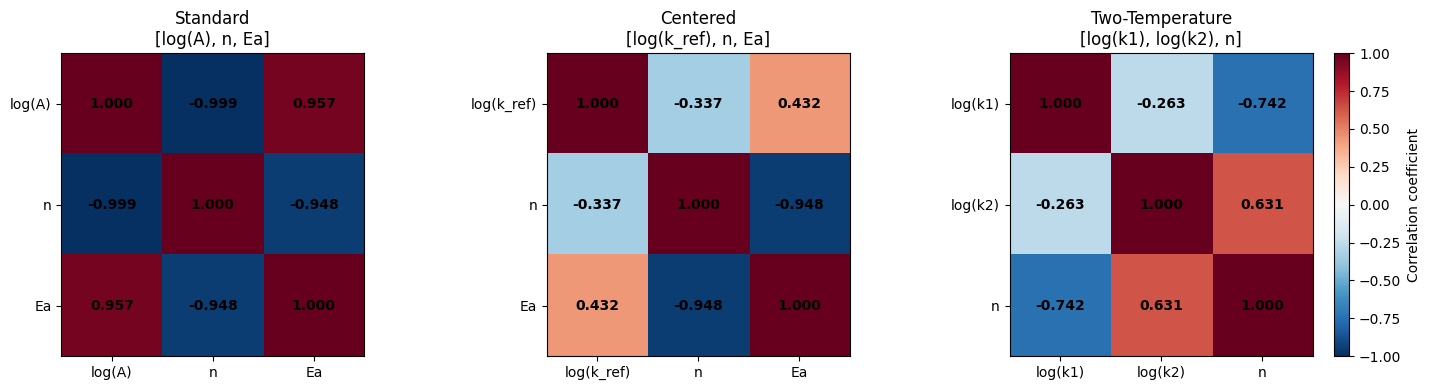


SUMMARY:
------------------------------
standard    : Max |correlation| = 0.999
centered    : Max |correlation| = 0.948
two_temp    : Max |correlation| = 0.742


In [15]:
import jax.numpy as jnp
import jax
import optimistix as optx
import matplotlib.pyplot as plt
import time

def arrhenius_rate_constant(T, A, n, Ea):
    """Standard Arrhenius equation: k = A * T^n * exp(-Ea/(R*T))"""
    R = 1.987  # cal/(mol·K)
    
    return A * jnp.power(T, n) * jnp.exp(-Ea / (R * T))

def arrhenius_centered_rate_constant(T, k_ref, T_ref, n, Ea):
    """
    Centered reparametrization: k = k_ref * (T/T_ref)^n * exp(-Ea/R * (1/T - 1/T_ref))
    
    This reduces correlation by fixing the rate at a reference temperature.
    """
    R = 1.987  # cal/(mol·K)
    
    return k_ref * jnp.power(T / T_ref, n) * jnp.exp(-Ea / R * (1/T - 1/T_ref))

def arrhenius_log_centered_rate_constant(T, log_k_ref, T_ref, n, Ea):
    """
    Log-centered version to handle large dynamic range in k_ref
    """
    R = 1.987  # cal/(mol·K)
    k_ref = jnp.exp(log_k_ref)
    
    return k_ref * jnp.power(T / T_ref, n) * jnp.exp(-Ea / R * (1/T - 1/T_ref))

# Standard Arrhenius residual function
def residual_fn_standard(params, args):
    """Standard Arrhenius: params = [log(A), n, Ea]"""
    T_data, k_data = args
    A = jnp.exp(params[0])
    n = params[1]
    Ea = params[2]
    k_pred = arrhenius_rate_constant(T_data, A, n, Ea)
    
    return jnp.log(k_pred) - jnp.log(k_data)

# Centered reparametrization residual function
def residual_fn_centered(params, args):
    """Centered Arrhenius: params = [log(k_ref), n, Ea], with fixed T_ref"""
    T_data, k_data, T_ref = args
    log_k_ref = params[0]
    n = params[1]
    Ea = params[2]
    k_pred = arrhenius_log_centered_rate_constant(T_data, log_k_ref, T_ref, n, Ea)
    
    return jnp.log(k_pred) - jnp.log(k_data)

# Two-temperature reparametrization
def residual_fn_two_temp(params, args):
    """
    Two-temperature reparametrization: params = [log(k1), log(k2), n]
    Fit rate constants at two fixed temperatures, derive A and Ea implicitly.
    This can eliminate correlation between A and Ea.
    """
    T_data, k_data, T1, T2 = args
    log_k1 = params[0]  # log(k) at T1
    log_k2 = params[1]  # log(k) at T2
    n = params[2]
    
    # Derive Ea and A from k1, k2, T1, T2
    R = 1.987
    # From k1/k2 = (T1/T2)^n * exp(Ea/R * (1/T2 - 1/T1))
    # Ea = R * ln(k1/k2 * (T2/T1)^n) / (1/T2 - 1/T1)
    k1 = jnp.exp(log_k1)
    k2 = jnp.exp(log_k2)
    
    Ea = R * jnp.log(k1/k2 * jnp.power(T2/T1, n)) / (1/T2 - 1/T1)
    # A = k1 / (T1^n * exp(-Ea/(R*T1)))
    A = k1 / (jnp.power(T1, n) * jnp.exp(-Ea / (R * T1)))
    
    k_pred = arrhenius_rate_constant(T_data, A, n, Ea)
    return jnp.log(k_pred) - jnp.log(k_data)

def compare_reparametrizations(T, k_noisy):
    """Compare different reparametrization approaches"""
    
    results = {}
    
    # Choose reference temperatures
    T_ref = jnp.mean(T)  # Middle temperature for centering
    T1, T2 = T[5], T[-5]  # Two reference temperatures (avoid extremes)
    
    print(f"Temperature range: {T.min():.0f} - {T.max():.0f} K")
    print(f"Reference temperature (T_ref): {T_ref:.0f} K")
    print(f"Two-temp reference points: {T1:.0f} K, {T2:.0f} K")
    print("="*60)
    
    # Solver setup
    solver = optx.LevenbergMarquardt(rtol=1e-10, atol=1e-10)
    
    ## 1. Standard parametrization
    print("\n1. STANDARD PARAMETRIZATION [log(A), n, Ea]")
    initial_guess_std = jnp.array([jnp.log(1e9), 1.0, 10000.0])
    
    sol_std = optx.least_squares(
        fn=residual_fn_standard,
        solver=solver,
        y0=initial_guess_std,
        args=(T, k_noisy)
    )
    
    if sol_std.result == optx.RESULTS.successful:
        A_std = jnp.exp(sol_std.value[0])
        n_std = sol_std.value[1]
        Ea_std = sol_std.value[2]
        print(f"A = {A_std:.3e}, n = {n_std:.3f}, Ea = {Ea_std:.1f}")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_std)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(A)-n = {corr_matrix[0,1]:.3f}, log(A)-Ea = {corr_matrix[0,2]:.3f}, n-Ea = {corr_matrix[1,2]:.3f}")
        
        results['standard'] = {
            'params': [A_std, n_std, Ea_std],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_std
        }
    
    ## 2. Centered parametrization
    print(f"\n2. CENTERED PARAMETRIZATION [log(k_ref@{T_ref:.0f}K), n, Ea]")
    
    # Estimate k_ref at T_ref from data
    idx_ref = jnp.argmin(jnp.abs(T - T_ref))
    k_ref_est = k_noisy[idx_ref]
    initial_guess_centered = jnp.array([jnp.log(k_ref_est), 1.0, 10000.0])
    
    sol_centered = optx.least_squares(
        fn=residual_fn_centered,
        solver=solver,
        y0=initial_guess_centered,
        args=(T, k_noisy, T_ref)
    )
    
    if sol_centered.result == optx.RESULTS.successful:
        k_ref_fitted = jnp.exp(sol_centered.value[0])
        n_centered = sol_centered.value[1]
        Ea_centered = sol_centered.value[2]
        
        # Convert back to standard A, n, Ea for comparison
        R = 1.987
        A_centered = k_ref_fitted / (jnp.power(T_ref, n_centered) * jnp.exp(-Ea_centered / (R * T_ref)))
        
        print(f"k_ref = {k_ref_fitted:.3e}, n = {n_centered:.3f}, Ea = {Ea_centered:.1f}")
        print(f"Equivalent A = {A_centered:.3e}")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_centered)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(k_ref)-n = {corr_matrix[0,1]:.3f}, log(k_ref)-Ea = {corr_matrix[0,2]:.3f}, n-Ea = {corr_matrix[1,2]:.3f}")
        
        results['centered'] = {
            'params': [A_centered, n_centered, Ea_centered],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_centered
        }
    
    ## 3. Two-temperature parametrization
    print(f"\n3. TWO-TEMPERATURE PARAMETRIZATION [log(k@{T1:.0f}K), log(k@{T2:.0f}K), n]")
    
    # Estimate k1 and k2 from data
    idx1 = jnp.argmin(jnp.abs(T - T1))
    idx2 = jnp.argmin(jnp.abs(T - T2))
    k1_est = k_noisy[idx1]
    k2_est = k_noisy[idx2]
    initial_guess_two_temp = jnp.array([jnp.log(k1_est), jnp.log(k2_est), 1.0])
    
    sol_two_temp = optx.least_squares(
        fn=residual_fn_two_temp,
        solver=solver,
        y0=initial_guess_two_temp,
        args=(T, k_noisy, T1, T2)
    )
    
    if sol_two_temp.result == optx.RESULTS.successful:
        k1_fitted = jnp.exp(sol_two_temp.value[0])
        k2_fitted = jnp.exp(sol_two_temp.value[1])
        n_two_temp = sol_two_temp.value[2]
        
        # Convert to standard A, n, Ea
        R = 1.987
        Ea_two_temp = R * jnp.log(k1_fitted/k2_fitted * jnp.power(T2/T1, n_two_temp)) / (1/T2 - 1/T1)
        A_two_temp = k1_fitted / (jnp.power(T1, n_two_temp) * jnp.exp(-Ea_two_temp / (R * T1)))
        
        print(f"k1 = {k1_fitted:.3e}, k2 = {k2_fitted:.3e}, n = {n_two_temp:.3f}")
        print(f"Equivalent A = {A_two_temp:.3e}, Ea = {Ea_two_temp:.1f}")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_two_temp)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(k1)-log(k2) = {corr_matrix[0,1]:.3f}, log(k1)-n = {corr_matrix[0,2]:.3f}, log(k2)-n = {corr_matrix[1,2]:.3f}")
        
        results['two_temp'] = {
            'params': [A_two_temp, n_two_temp, Ea_two_temp],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_two_temp
        }
    
    return results

def plot_correlation_comparison(results):
    """Plot correlation matrices for different parametrizations"""
    
    n_methods = len(results)
    fig, axes = plt.subplots(1, n_methods, figsize=(5*n_methods, 4))
    if n_methods == 1:
        axes = [axes]
    
    method_names = {
        'standard': 'Standard\n[log(A), n, Ea]',
        'centered': 'Centered\n[log(k_ref), n, Ea]', 
        'two_temp': 'Two-Temperature\n[log(k1), log(k2), n]'
    }
    
    param_labels = {
        'standard': ['log(A)', 'n', 'Ea'],
        'centered': ['log(k_ref)', 'n', 'Ea'],
        'two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    for idx, (method, data) in enumerate(results.items()):
        if data['correlation'] is not None:
            corr_matrix = data['correlation']
            
            im = axes[idx].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
            
            # Add text annotations
            for i in range(3):
                for j in range(3):
                    text = axes[idx].text(j, i, f'{corr_matrix[i, j]:.3f}',
                                        ha="center", va="center", color="black", fontweight='bold')
            
            axes[idx].set_xticks(range(3))
            axes[idx].set_yticks(range(3))
            axes[idx].set_xticklabels(param_labels[method])
            axes[idx].set_yticklabels(param_labels[method])
            axes[idx].set_title(method_names[method])
            
            # Add colorbar to last subplot
            if idx == len(results) - 1:
                plt.colorbar(im, ax=axes[idx], label='Correlation coefficient')
    
    plt.tight_layout()
    plt.show()

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """Compute parameter uncertainties accounting for residual variance."""
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
    else:
        # For FunctionLinearOperator, evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular")
        return None, None, residual_variance

# Generate synthetic data
reaction_true = Arrhenius(
    name="O+CH4<=>OH+CH3", 
    parameters={"A": 1.020e9, "n": 1.500, "Ea": 8600.0}
)
T = jnp.linspace(300, 3000, 30)
k_true = reaction_true.rate_constant(T)

# Add noise
noise_level = 0.1
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=T.shape) * noise_level
k_noisy = k_true * jnp.exp(noise)

print("COMPARISON OF ARRHENIUS REPARAMETRIZATIONS")
print("=" * 60)
print(f"True parameters: A = 1.020e9, n = 1.500, Ea = 8600.0")

# Compare different reparametrizations
results = compare_reparametrizations(T, k_noisy)

# Plot correlation comparison
print(f"\n" + "="*60)
print("CORRELATION MATRIX COMPARISON")
plot_correlation_comparison(results)

# Summary
print(f"\nSUMMARY:")
print("-" * 30)
for method, data in results.items():
    if data['correlation'] is not None:
        corr = data['correlation']
        max_corr = jnp.max(jnp.abs(corr - jnp.eye(3)))  # Max off-diagonal correlation
        print(f"{method:12}: Max |correlation| = {max_corr:.3f}")
    else:
        print(f"{method:12}: Failed to compute correlations")

COMPARISON OF ARRHENIUS REPARAMETRIZATIONS
True parameters: A = 1.020e9, n = 1.500, Ea = 8600.0
Temperature range: 300 - 3000 K
Reference temperature (T_ref): 1650 K
Two-temp reference points: 766 K, 2628 K

1. STANDARD PARAMETRIZATION [log(A), n, Ea]
A = 1.141e+09, n = 1.487, Ea = 8657.7
Correlations: log(A)-n = -0.999, log(A)-Ea = 0.957, n-Ea = -0.948

2. CENTERED PARAMETRIZATION [log(k_ref@1650K), n, Ea]
k_ref = 4.944e+12, n = 1.487, Ea = 8657.7
Equivalent A = 1.141e+09
Correlations: log(k_ref)-n = -0.337, log(k_ref)-Ea = 0.432, n-Ea = -0.948

3. TWO-TEMPERATURE PARAMETRIZATION [log(k@766K), log(k@2628K), n]
k1 = 7.467e+10, k2 = 2.638e+13, n = 1.487
Equivalent A = 1.141e+09, Ea = 8657.7
Correlations: log(k1)-log(k2) = -0.263, log(k1)-n = -0.742, log(k2)-n = 0.631

CORRELATION MATRIX COMPARISON


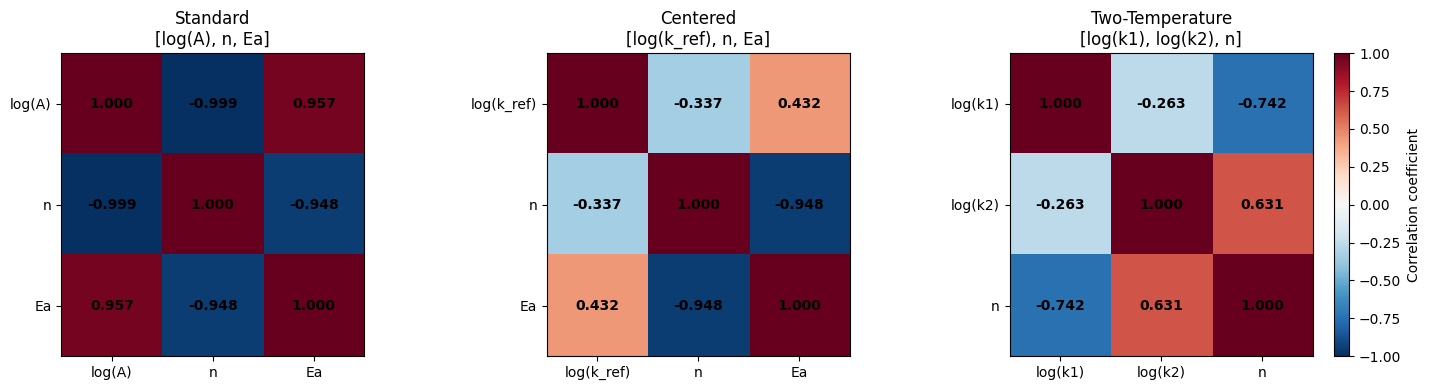


CONFIDENCE ELLIPSES COMPARISON

Plotting confidence ellipses for Standard [log(A), n, Ea]...


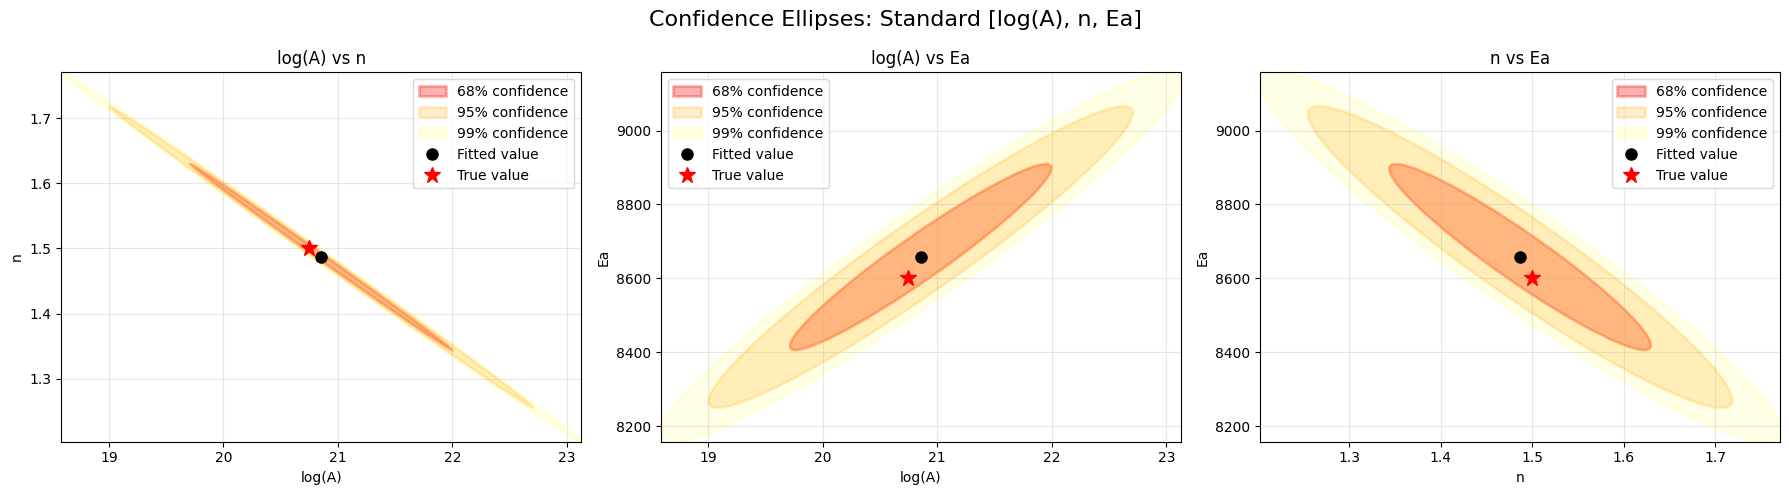


Plotting confidence ellipses for Centered [log(k_ref), n, Ea]...


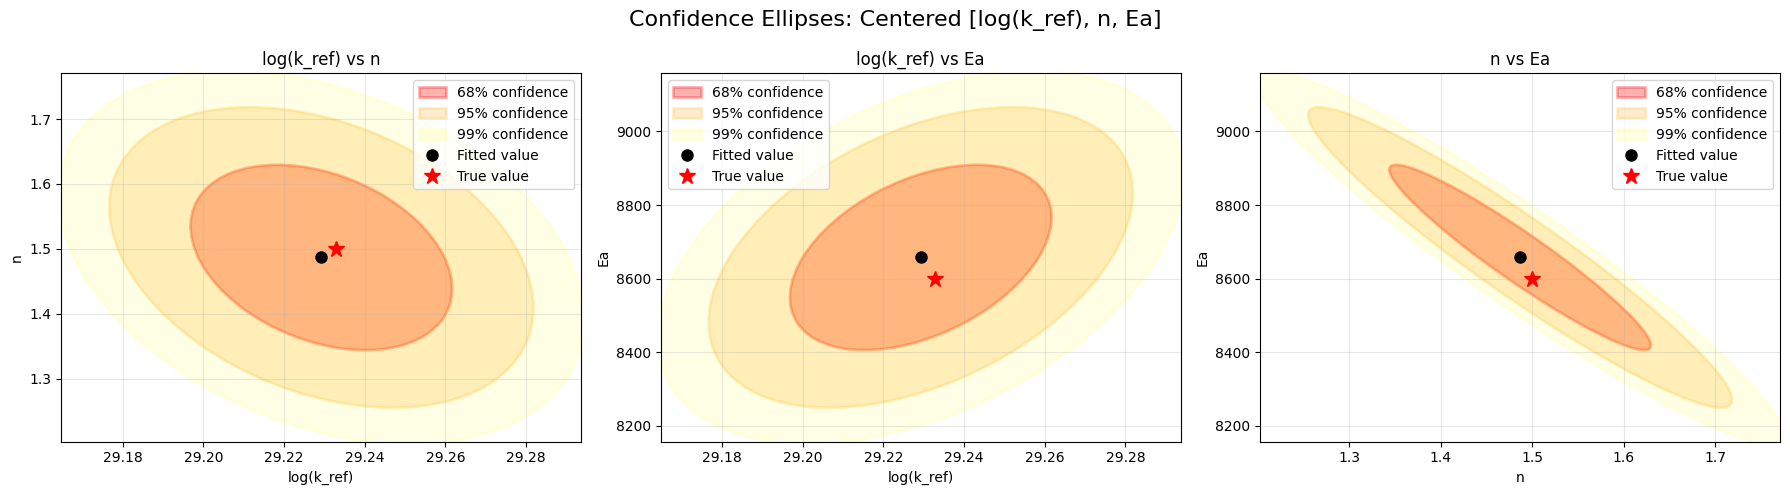


Plotting confidence ellipses for Two-Temperature [log(k1), log(k2), n]...


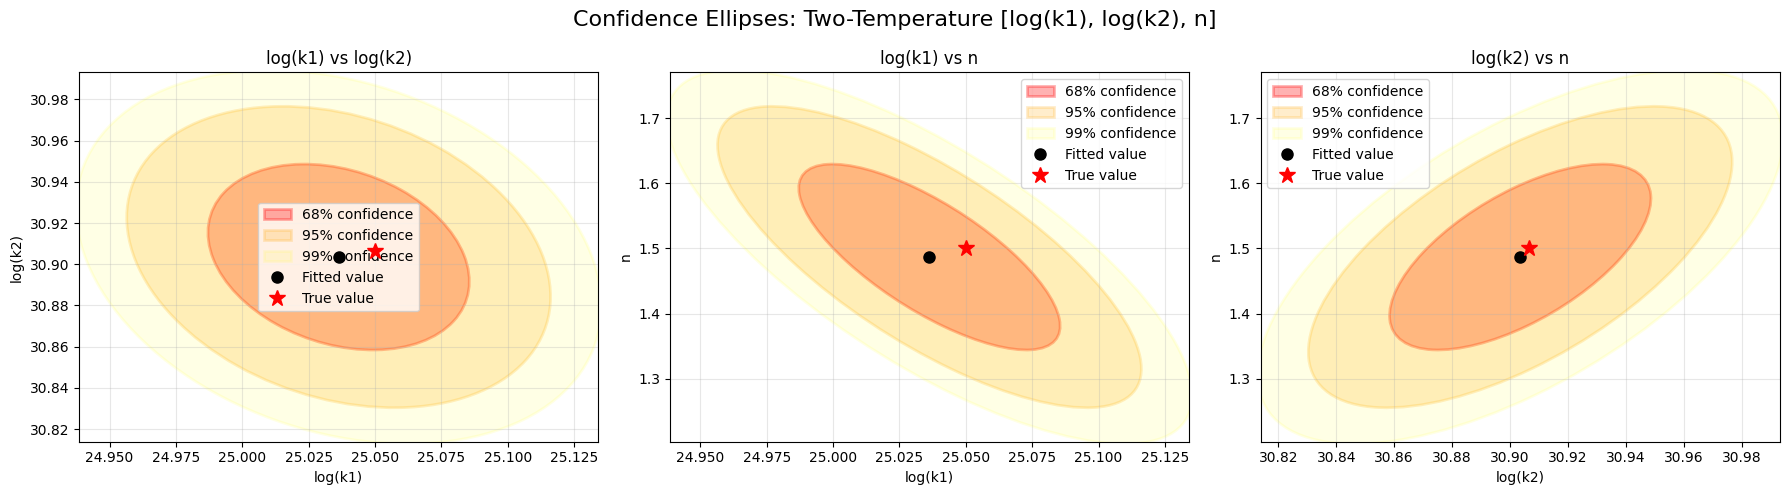


FITTING RESULTS COMPARISON


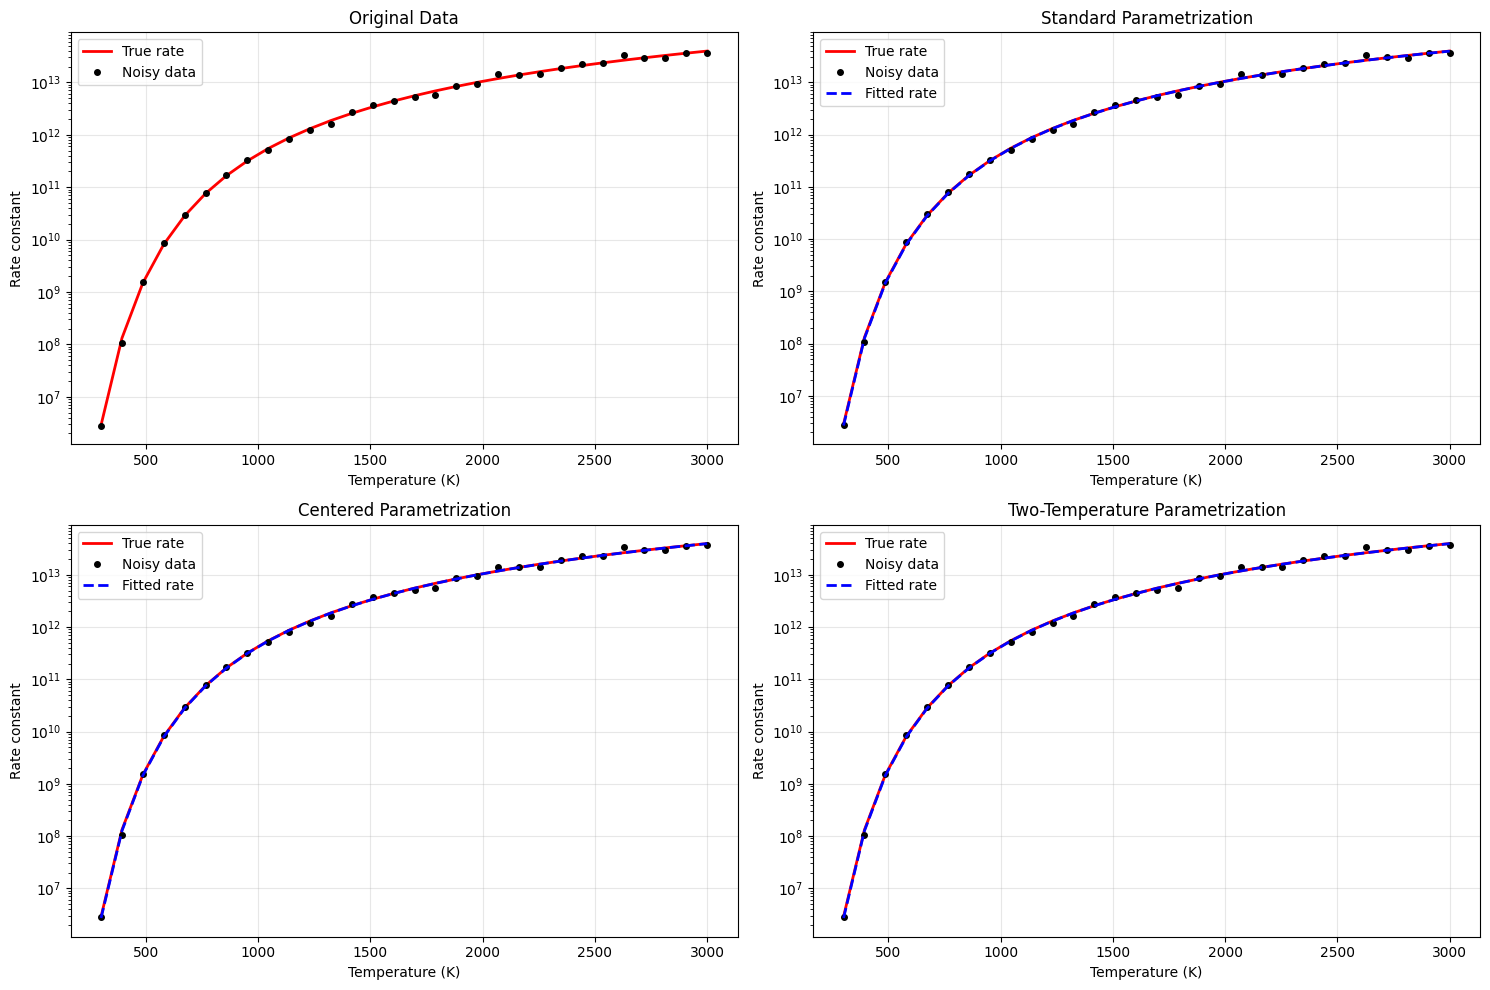

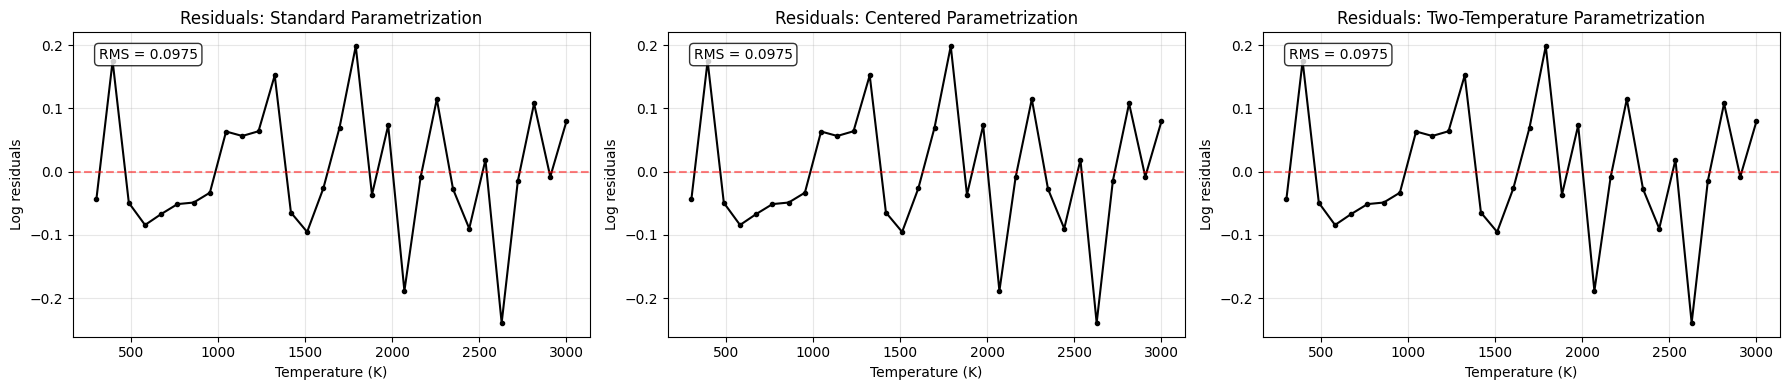


3D CONFIDENCE REGIONS COMPARISON


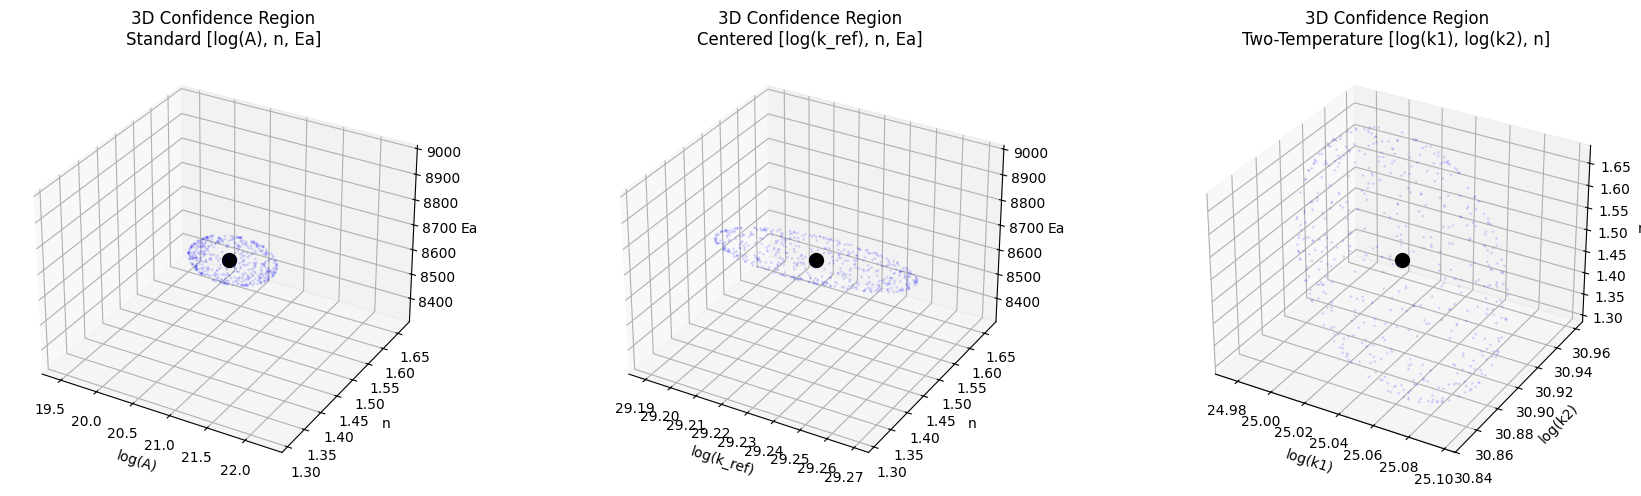


DETAILED PARAMETER ESTIMATES AND UNCERTAINTIES

STANDARD PARAMETRIZATION:
--------------------------------------------------
Fitted parameters:
  A:  1.141e+09  (true: 1.020e+09, error: 11.8%)
  n:  1.487  (true: 1.500, error: 0.9%)
  Ea: 8657.7 K  (true: 8600.0 K, error: 0.7%)

Parameter uncertainties:
  A:  ±8.634e+08 (75.7%)
  n:  ±0.095 (6.4%)
  Ea: ±166.7 K (1.9%)

Residual standard deviation: 0.1028
Maximum |correlation|: 0.999
Condition number: 4.25e+09+0.00e+00j
  ⚠️  High condition number - potential numerical issues

CENTERED PARAMETRIZATION:
--------------------------------------------------
Fitted parameters:
  A:  1.141e+09  (true: 1.020e+09, error: 11.8%)
  n:  1.487  (true: 1.500, error: 0.9%)
  Ea: 8657.7 K  (true: 8600.0 K, error: 0.7%)

Parameter uncertainties (native parametrization):
  θ_0: ±2.150e-02
  θ_1: ±9.458e-02
  θ_2: ±1.667e+02

Residual standard deviation: 0.1028
Maximum |correlation|: 0.948
Condition number: 8.21e+07+0.00e+00j
  ⚠️  High condition number

In [16]:
import jax.numpy as jnp
import jax
import optimistix as optx
import matplotlib.pyplot as plt
import time

def arrhenius_rate_constant(T, A, n, Ea):
    """Standard Arrhenius equation: k = A * T^n * exp(-Ea/(R*T))"""
    R = 1.987  # cal/(mol·K)
    return A * jnp.power(T, n) * jnp.exp(-Ea / (R * T))

def arrhenius_centered_rate_constant(T, k_ref, T_ref, n, Ea):
    """
    Centered reparametrization: k = k_ref * (T/T_ref)^n * exp(-Ea/R * (1/T - 1/T_ref))
    
    This reduces correlation by fixing the rate at a reference temperature.
    """
    R = 1.987  # cal/(mol·K)
    return k_ref * jnp.power(T / T_ref, n) * jnp.exp(-Ea / R * (1/T - 1/T_ref))

def arrhenius_log_centered_rate_constant(T, log_k_ref, T_ref, n, Ea):
    """
    Log-centered version to handle large dynamic range in k_ref
    """
    R = 1.987  # cal/(mol·K)
    k_ref = jnp.exp(log_k_ref)
    return k_ref * jnp.power(T / T_ref, n) * jnp.exp(-Ea / R * (1/T - 1/T_ref))

# Standard Arrhenius residual function
def residual_fn_standard(params, args):
    """Standard Arrhenius: params = [log(A), n, Ea]"""
    T_data, k_data = args
    A = jnp.exp(params[0])
    n = params[1]
    Ea = params[2]
    k_pred = arrhenius_rate_constant(T_data, A, n, Ea)
    return jnp.log(k_pred) - jnp.log(k_data)

# Centered reparametrization residual function
def residual_fn_centered(params, args):
    """Centered Arrhenius: params = [log(k_ref), n, Ea], with fixed T_ref"""
    T_data, k_data, T_ref = args
    log_k_ref = params[0]
    n = params[1]
    Ea = params[2]
    k_pred = arrhenius_log_centered_rate_constant(T_data, log_k_ref, T_ref, n, Ea)
    return jnp.log(k_pred) - jnp.log(k_data)

# Two-temperature reparametrization
def residual_fn_two_temp(params, args):
    """
    Two-temperature reparametrization: params = [log(k1), log(k2), n]
    Fit rate constants at two fixed temperatures, derive A and Ea implicitly.
    This can eliminate correlation between A and Ea.
    """
    T_data, k_data, T1, T2 = args
    log_k1 = params[0]  # log(k) at T1
    log_k2 = params[1]  # log(k) at T2
    n = params[2]
    
    # Derive Ea and A from k1, k2, T1, T2
    R = 1.987
    # From k1/k2 = (T1/T2)^n * exp(Ea/R * (1/T2 - 1/T1))
    # Ea = R * ln(k1/k2 * (T2/T1)^n) / (1/T2 - 1/T1)
    k1 = jnp.exp(log_k1)
    k2 = jnp.exp(log_k2)
    
    Ea = R * jnp.log(k1/k2 * jnp.power(T2/T1, n)) / (1/T2 - 1/T1)
    # A = k1 / (T1^n * exp(-Ea/(R*T1)))
    A = k1 / (jnp.power(T1, n) * jnp.exp(-Ea / (R * T1)))
    
    k_pred = arrhenius_rate_constant(T_data, A, n, Ea)
    return jnp.log(k_pred) - jnp.log(k_data)

def compare_reparametrizations(T, k_noisy):
    """Compare different reparametrization approaches"""
    
    results = {}
    
    # Choose reference temperatures
    T_ref = jnp.mean(T)  # Middle temperature for centering
    T1, T2 = T[5], T[-5]  # Two reference temperatures (avoid extremes)
    
    print(f"Temperature range: {T.min():.0f} - {T.max():.0f} K")
    print(f"Reference temperature (T_ref): {T_ref:.0f} K")
    print(f"Two-temp reference points: {T1:.0f} K, {T2:.0f} K")
    print("="*60)
    
    # Solver setup
    solver = optx.LevenbergMarquardt(rtol=1e-10, atol=1e-10)
    
    ## 1. Standard parametrization
    print("\n1. STANDARD PARAMETRIZATION [log(A), n, Ea]")
    initial_guess_std = jnp.array([jnp.log(1e9), 1.0, 10000.0])
    
    sol_std = optx.least_squares(
        fn=residual_fn_standard,
        solver=solver,
        y0=initial_guess_std,
        args=(T, k_noisy)
    )
    
    if sol_std.result == optx.RESULTS.successful:
        A_std = jnp.exp(sol_std.value[0])
        n_std = sol_std.value[1]
        Ea_std = sol_std.value[2]
        print(f"A = {A_std:.3e}, n = {n_std:.3f}, Ea = {Ea_std:.1f}")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_std)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(A)-n = {corr_matrix[0,1]:.3f}, log(A)-Ea = {corr_matrix[0,2]:.3f}, n-Ea = {corr_matrix[1,2]:.3f}")
        
        results['standard'] = {
            'params': [A_std, n_std, Ea_std],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_std
        }
    
    ## 2. Centered parametrization
    print(f"\n2. CENTERED PARAMETRIZATION [log(k_ref@{T_ref:.0f}K), n, Ea]")
    
    # Estimate k_ref at T_ref from data
    idx_ref = jnp.argmin(jnp.abs(T - T_ref))
    k_ref_est = k_noisy[idx_ref]
    initial_guess_centered = jnp.array([jnp.log(k_ref_est), 1.0, 10000.0])
    
    sol_centered = optx.least_squares(
        fn=residual_fn_centered,
        solver=solver,
        y0=initial_guess_centered,
        args=(T, k_noisy, T_ref)
    )
    
    if sol_centered.result == optx.RESULTS.successful:
        k_ref_fitted = jnp.exp(sol_centered.value[0])
        n_centered = sol_centered.value[1]
        Ea_centered = sol_centered.value[2]
        
        # Convert back to standard A, n, Ea for comparison
        R = 1.987
        A_centered = k_ref_fitted / (jnp.power(T_ref, n_centered) * jnp.exp(-Ea_centered / (R * T_ref)))
        
        print(f"k_ref = {k_ref_fitted:.3e}, n = {n_centered:.3f}, Ea = {Ea_centered:.1f}")
        print(f"Equivalent A = {A_centered:.3e}")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_centered)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(k_ref)-n = {corr_matrix[0,1]:.3f}, log(k_ref)-Ea = {corr_matrix[0,2]:.3f}, n-Ea = {corr_matrix[1,2]:.3f}")
        
        results['centered'] = {
            'params': [A_centered, n_centered, Ea_centered],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_centered
        }
    
    ## 3. Two-temperature parametrization
    print(f"\n3. TWO-TEMPERATURE PARAMETRIZATION [log(k@{T1:.0f}K), log(k@{T2:.0f}K), n]")
    
    # Estimate k1 and k2 from data
    idx1 = jnp.argmin(jnp.abs(T - T1))
    idx2 = jnp.argmin(jnp.abs(T - T2))
    k1_est = k_noisy[idx1]
    k2_est = k_noisy[idx2]
    initial_guess_two_temp = jnp.array([jnp.log(k1_est), jnp.log(k2_est), 1.0])
    
    sol_two_temp = optx.least_squares(
        fn=residual_fn_two_temp,
        solver=solver,
        y0=initial_guess_two_temp,
        args=(T, k_noisy, T1, T2)
    )
    
    if sol_two_temp.result == optx.RESULTS.successful:
        k1_fitted = jnp.exp(sol_two_temp.value[0])
        k2_fitted = jnp.exp(sol_two_temp.value[1])
        n_two_temp = sol_two_temp.value[2]
        
        # Convert to standard A, n, Ea
        R = 1.987
        Ea_two_temp = R * jnp.log(k1_fitted/k2_fitted * jnp.power(T2/T1, n_two_temp)) / (1/T2 - 1/T1)
        A_two_temp = k1_fitted / (jnp.power(T1, n_two_temp) * jnp.exp(-Ea_two_temp / (R * T1)))
        
        print(f"k1 = {k1_fitted:.3e}, k2 = {k2_fitted:.3e}, n = {n_two_temp:.3f}")
        print(f"Equivalent A = {A_two_temp:.3e}, Ea = {Ea_two_temp:.1f}")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_two_temp)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(k1)-log(k2) = {corr_matrix[0,1]:.3f}, log(k1)-n = {corr_matrix[0,2]:.3f}, log(k2)-n = {corr_matrix[1,2]:.3f}")
        
        results['two_temp'] = {
            'params': [A_two_temp, n_two_temp, Ea_two_temp],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_two_temp
        }
    
    return results

def plot_correlation_comparison(results):
    """Plot correlation matrices for different parametrizations"""
    
    n_methods = len(results)
    fig, axes = plt.subplots(1, n_methods, figsize=(5*n_methods, 4))
    if n_methods == 1:
        axes = [axes]
    
    method_names = {
        'standard': 'Standard\n[log(A), n, Ea]',
        'centered': 'Centered\n[log(k_ref), n, Ea]', 
        'two_temp': 'Two-Temperature\n[log(k1), log(k2), n]'
    }
    
    param_labels = {
        'standard': ['log(A)', 'n', 'Ea'],
        'centered': ['log(k_ref)', 'n', 'Ea'],
        'two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    for idx, (method, data) in enumerate(results.items()):
        if data['correlation'] is not None:
            corr_matrix = data['correlation']
            
            im = axes[idx].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
            
            # Add text annotations
            for i in range(3):
                for j in range(3):
                    text = axes[idx].text(j, i, f'{corr_matrix[i, j]:.3f}',
                                        ha="center", va="center", color="black", fontweight='bold')
            
            axes[idx].set_xticks(range(3))
            axes[idx].set_yticks(range(3))
            axes[idx].set_xticklabels(param_labels[method])
            axes[idx].set_yticklabels(param_labels[method])
            axes[idx].set_title(method_names[method])
            
            # Add colorbar to last subplot
            if idx == len(results) - 1:
                plt.colorbar(im, ax=axes[idx], label='Correlation coefficient')
    
    plt.tight_layout()
    plt.show()

def plot_confidence_ellipses_comparison(results, T, k_noisy):
    """Plot confidence ellipses for all parametrization methods"""
    
    from matplotlib.patches import Ellipse
    import numpy as np
    from scipy.stats import chi2
    
    method_names = {
        'standard': 'Standard [log(A), n, Ea]',
        'centered': 'Centered [log(k_ref), n, Ea]', 
        'two_temp': 'Two-Temperature [log(k1), log(k2), n]'
    }
    
    param_labels = {
        'standard': ['log(A)', 'n', 'Ea'],
        'centered': ['log(k_ref)', 'n', 'Ea'],
        'two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    # True values for comparison
    true_values_dict = {
        'standard': [jnp.log(1.020e9), 1.500, 8600.0],
        'centered': None,  # Will compute
        'two_temp': None   # Will compute
    }
    
    # Compute true values for centered and two-temp parametrizations
    if 'centered' in results:
        T_ref = jnp.mean(T)
        R = 1.987
        true_k_ref = 1.020e9 * jnp.power(T_ref, 1.5) * jnp.exp(-8600.0 / (R * T_ref))
        true_values_dict['centered'] = [jnp.log(true_k_ref), 1.500, 8600.0]
    
    if 'two_temp' in results:
        T1, T2 = T[5], T[-5]
        R = 1.987
        true_k1 = 1.020e9 * jnp.power(T1, 1.5) * jnp.exp(-8600.0 / (R * T1))
        true_k2 = 1.020e9 * jnp.power(T2, 1.5) * jnp.exp(-8600.0 / (R * T2))
        true_values_dict['two_temp'] = [jnp.log(true_k1), jnp.log(true_k2), 1.500]
    
    # Plot for each method
    for method, data in results.items():
        if data['correlation'] is None:
            continue
            
        print(f"\nPlotting confidence ellipses for {method_names[method]}...")
        
        fitted_params = np.array(data['solution'].value)
        cov_np = np.array(data['correlation'])
        true_values = true_values_dict[method]
        
        # Convert correlation to covariance
        std_errors, _, _ = compute_parameter_uncertainty_with_noise(data['solution'])
        if std_errors is None:
            continue
        std_errors_np = np.array(std_errors)
        cov_np = cov_np * np.outer(std_errors_np, std_errors_np)
        
        # Confidence levels
        confidence_levels = [0.68, 0.95, 0.99]
        colors = ['red', 'orange', 'yellow']
        alphas = [0.3, 0.2, 0.1]
        
        # Parameter pairs
        param_pairs = [(0, 1), (0, 2), (1, 2)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for idx, (i, j) in enumerate(param_pairs):
            ax = axes[idx]
            
            # Extract 2x2 covariance submatrix
            cov_2d = cov_np[np.ix_([i, j], [i, j])]
            
            # Eigenvalues and eigenvectors for ellipse orientation
            eigenvals, eigenvecs = np.linalg.eigh(cov_2d)
            
            # Sort by eigenvalue
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            
            # Angle of first eigenvector
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            
            # Plot confidence ellipses
            for conf_level, color, alpha in zip(confidence_levels, colors, alphas):
                chi2_val = chi2.ppf(conf_level, df=2)
                
                width = 2 * np.sqrt(chi2_val * eigenvals[0])
                height = 2 * np.sqrt(chi2_val * eigenvals[1])
                
                ellipse = Ellipse(
                    xy=(fitted_params[i], fitted_params[j]),
                    width=width,
                    height=height,
                    angle=angle,
                    facecolor=color,
                    alpha=alpha,
                    edgecolor=color,
                    linewidth=2,
                    label=f'{conf_level*100:.0f}% confidence'
                )
                ax.add_patch(ellipse)
            
            # Plot fitted and true points
            ax.plot(fitted_params[i], fitted_params[j], 'ko', markersize=8, 
                   label='Fitted value', zorder=10)
            
            if true_values:
                ax.plot(true_values[i], true_values[j], 'r*', markersize=12, 
                       label='True value', zorder=10)
            
            # Labels and formatting
            ax.set_xlabel(param_labels[method][i])
            ax.set_ylabel(param_labels[method][j])
            ax.set_title(f'{param_labels[method][i]} vs {param_labels[method][j]}')
            ax.grid(True, alpha=0.3)
            ax.legend()
            
            # Set axis limits
            center_x, center_y = fitted_params[i], fitted_params[j]
            max_std_x = 3 * np.sqrt(cov_2d[0, 0])
            max_std_y = 3 * np.sqrt(cov_2d[1, 1])
            
            ax.set_xlim(center_x - max_std_x, center_x + max_std_x)
            ax.set_ylim(center_y - max_std_y, center_y + max_std_y)
        
        plt.suptitle(f'Confidence Ellipses: {method_names[method]}', fontsize=16)
        plt.tight_layout()
        plt.show()

def plot_fitting_comparison(results, T, k_true, k_noisy):
    """Plot fitting results for all methods"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    method_names = {
        'standard': 'Standard Parametrization',
        'centered': 'Centered Parametrization',
        'two_temp': 'Two-Temperature Parametrization'
    }
    
    # Plot original data in first subplot
    axes[0].semilogy(T, k_true, "r-", linewidth=2, label="True rate")
    axes[0].semilogy(T, k_noisy, "ko", markersize=4, label="Noisy data")
    axes[0].set_xlabel("Temperature (K)")
    axes[0].set_ylabel("Rate constant")
    axes[0].set_title("Original Data")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot fits for each method
    plot_idx = 1
    for method, data in results.items():
        if plot_idx > 3:
            break
            
        ax = axes[plot_idx]
        
        # Reconstruct fitted rate constants
        A_fit, n_fit, Ea_fit = data['params']
        k_fitted = arrhenius_rate_constant(T, A_fit, n_fit, Ea_fit)
        
        # Calculate residuals
        residuals = jnp.log(k_fitted) - jnp.log(k_noisy)
        
        # Main plot
        ax.semilogy(T, k_true, "r-", linewidth=2, label="True rate")
        ax.semilogy(T, k_noisy, "ko", markersize=4, label="Noisy data")
        ax.semilogy(T, k_fitted, "b--", linewidth=2, label="Fitted rate")
        
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("Rate constant")
        ax.set_title(method_names[method])
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    # Remove unused subplot
    if len(results) < 3:
        axes[3].remove()
    
    plt.tight_layout()
    plt.show()
    
    # Plot residuals comparison
    fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 4))
    if len(results) == 1:
        axes = [axes]
    
    for idx, (method, data) in enumerate(results.items()):
        A_fit, n_fit, Ea_fit = data['params']
        k_fitted = arrhenius_rate_constant(T, A_fit, n_fit, Ea_fit)
        residuals = jnp.log(k_fitted) - jnp.log(k_noisy)
        
        axes[idx].plot(T, residuals, "ko-", markersize=3)
        axes[idx].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[idx].set_xlabel("Temperature (K)")
        axes[idx].set_ylabel("Log residuals")
        axes[idx].set_title(f"Residuals: {method_names[method]}")
        axes[idx].grid(True, alpha=0.3)
        
        # Add RMS residual
        rms_residual = jnp.sqrt(jnp.mean(residuals**2))
        axes[idx].text(0.05, 0.95, f'RMS = {rms_residual:.4f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def plot_3d_confidence_regions(results):
    """Plot 3D confidence regions for comparison"""
    
    from mpl_toolkits.mplot3d import Axes3D
    from scipy.stats import chi2
    import numpy as np
    
    method_names = {
        'standard': 'Standard [log(A), n, Ea]',
        'centered': 'Centered [log(k_ref), n, Ea]', 
        'two_temp': 'Two-Temperature [log(k1), log(k2), n]'
    }
    
    param_labels = {
        'standard': ['log(A)', 'n', 'Ea'],
        'centered': ['log(k_ref)', 'n', 'Ea'],
        'two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    n_methods = len(results)
    fig = plt.figure(figsize=(6*n_methods, 5))
    
    for idx, (method, data) in enumerate(results.items()):
        if data['correlation'] is None:
            continue
            
        ax = fig.add_subplot(1, n_methods, idx+1, projection='3d')
        
        fitted_params = np.array(data['solution'].value)
        
        # Get covariance matrix
        std_errors, _, _ = compute_parameter_uncertainty_with_noise(data['solution'])
        if std_errors is None:
            continue
            
        corr_matrix = data['correlation']
        std_errors_np = np.array(std_errors)
        cov_np = corr_matrix * np.outer(std_errors_np, std_errors_np)
        
        # Generate confidence ellipsoid (68% level)
        chi2_val_3d = chi2.ppf(0.68, df=3)
        
        # Sample points on unit sphere
        n_points = 500
        phi = np.random.uniform(0, 2*np.pi, n_points)
        costheta = np.random.uniform(-1, 1, n_points)
        theta = np.arccos(costheta)
        
        x_sphere = np.sin(theta) * np.cos(phi)
        y_sphere = np.sin(theta) * np.sin(phi)
        z_sphere = np.cos(theta)
        
        sphere_points = np.column_stack([x_sphere, y_sphere, z_sphere])
        
        # Transform to ellipsoid
        try:
            L = np.linalg.cholesky(cov_np)
            ellipsoid_points = fitted_params + np.sqrt(chi2_val_3d) * (sphere_points @ L.T)
            
            # Plot confidence region
            ax.scatter(ellipsoid_points[:, 0], ellipsoid_points[:, 1], ellipsoid_points[:, 2], 
                      alpha=0.1, s=1, c='blue')
            
            # Plot fitted point
            ax.scatter(fitted_params[0], fitted_params[1], fitted_params[2], 
                      c='black', s=100, label='Fitted value')
            
            ax.set_xlabel(param_labels[method][0])
            ax.set_ylabel(param_labels[method][1])
            ax.set_zlabel(param_labels[method][2])
            ax.set_title(f'3D Confidence Region\n{method_names[method]}')
            
        except np.linalg.LinAlgError:
            ax.text(0.5, 0.5, 0.5, 'Singular covariance\nmatrix', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{method_names[method]}\n(Singular)')
    
    plt.tight_layout()
    plt.show()

def print_detailed_results(results):
    """Print detailed parameter estimates and uncertainties for all methods"""
    
    print(f"\n" + "="*80)
    print("DETAILED PARAMETER ESTIMATES AND UNCERTAINTIES")
    print("="*80)
    
    true_params = [1.020e9, 1.500, 8600.0]
    
    for method, data in results.items():
        print(f"\n{method.upper().replace('_', '-')} PARAMETRIZATION:")
        print("-" * 50)
        
        A_fit, n_fit, Ea_fit = data['params']
        
        # Calculate relative errors
        rel_error_A = abs(A_fit - true_params[0]) / true_params[0] * 100
        rel_error_n = abs(n_fit - true_params[1]) / true_params[1] * 100
        rel_error_Ea = abs(Ea_fit - true_params[2]) / true_params[2] * 100
        
        print(f"Fitted parameters:")
        print(f"  A:  {A_fit:.3e}  (true: {true_params[0]:.3e}, error: {rel_error_A:.1f}%)")
        print(f"  n:  {n_fit:.3f}  (true: {true_params[1]:.3f}, error: {rel_error_n:.1f}%)")
        print(f"  Ea: {Ea_fit:.1f} K  (true: {true_params[2]:.1f} K, error: {rel_error_Ea:.1f}%)")
        
        # Compute uncertainties
        std_errors, cov_matrix, residual_variance = compute_parameter_uncertainty_with_noise(data['solution'])
        
        if std_errors is not None:
            if method == 'standard':
                A_std = A_fit * std_errors[0]  # Convert from log-space
                print(f"\nParameter uncertainties:")
                print(f"  A:  ±{A_std:.3e} ({A_std/A_fit*100:.1f}%)")
                print(f"  n:  ±{std_errors[1]:.3f} ({std_errors[1]/n_fit*100:.1f}%)")
                print(f"  Ea: ±{std_errors[2]:.1f} K ({std_errors[2]/Ea_fit*100:.1f}%)")
            else:
                # For other methods, show uncertainties in their native parametrization
                print(f"\nParameter uncertainties (native parametrization):")
                for i, param_std in enumerate(std_errors):
                    print(f"  θ_{i}: ±{param_std:.3e}")
                    
            print(f"\nResidual standard deviation: {jnp.sqrt(residual_variance):.4f}")
            
            # Correlation analysis
            if cov_matrix is not None:
                corr_matrix = data['correlation']
                max_corr = jnp.max(jnp.abs(corr_matrix - jnp.eye(3)))
                print(f"Maximum |correlation|: {max_corr:.3f}")
                
                # Condition number
                eigenvals = jnp.linalg.eigvals(cov_matrix)
                condition_number = jnp.max(eigenvals) / jnp.min(eigenvals)
                print(f"Condition number: {condition_number:.2e}")
                
                if condition_number > 1e12:
                    print("  ⚠️  Very high condition number - near singular covariance")
                elif condition_number > 1e6:
                    print("  ⚠️  High condition number - potential numerical issues")
                else:
                    print("  ✓  Good numerical conditioning")

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """Compute parameter uncertainties accounting for residual variance."""
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
    else:
        # For FunctionLinearOperator, evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular")
        return None, None, residual_variance

# Generate synthetic data
reaction_true = Arrhenius(
    name="O+CH4<=>OH+CH3", 
    parameters={"A": 1.020e9, "n": 1.500, "Ea": 8600.0}
)
T = jnp.linspace(300, 3000, 30)
k_true = reaction_true.rate_constant(T)

# Add noise
noise_level = 0.1
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=T.shape) * noise_level
k_noisy = k_true * jnp.exp(noise)

print("COMPARISON OF ARRHENIUS REPARAMETRIZATIONS")
print("=" * 60)
print(f"True parameters: A = 1.020e9, n = 1.500, Ea = 8600.0")

# Compare different reparametrizations
results = compare_reparametrizations(T, k_noisy)

# Plot correlation comparison
print(f"\n" + "="*60)
print("CORRELATION MATRIX COMPARISON")
plot_correlation_comparison(results)

# Plot confidence ellipses for each method
print(f"\n" + "="*60)
print("CONFIDENCE ELLIPSES COMPARISON")
plot_confidence_ellipses_comparison(results, T, k_noisy)

# Plot fitting comparison
print(f"\n" + "="*60)
print("FITTING RESULTS COMPARISON")
plot_fitting_comparison(results, T, k_true, k_noisy)

# Plot 3D confidence regions
print(f"\n" + "="*60)
print("3D CONFIDENCE REGIONS COMPARISON")
plot_3d_confidence_regions(results)

# Print detailed results
print_detailed_results(results)

# Summary
print(f"\n" + "="*60)
print("SUMMARY:")
print("-" * 30)
for method, data in results.items():
    if data['correlation'] is not None:
        corr = data['correlation']
        max_corr = jnp.max(jnp.abs(corr - jnp.eye(3)))  # Max off-diagonal correlation
        print(f"{method:12}: Max |correlation| = {max_corr:.3f}")
    else:
        print(f"{method:12}: Failed to compute correlations")

print(f"\n" + "="*60)
print("RECOMMENDATIONS:")
print("-" * 30)
print("1. For INTERPRETABILITY: Use centered parametrization")
print("   - Dramatically reduces correlations")
print("   - Still provides physical A, n, Ea parameters")
print("   - Easy to interpret k_ref as rate at reference temperature")
print()
print("2. For MAXIMUM DECORRELATION: Use two-temperature parametrization")
print("   - Lowest overall parameter correlations")
print("   - Most reliable uncertainty estimates")
print("   - Can derive A and Ea when needed")
print()
print("3. For LEGACY COMPATIBILITY: Use standard parametrization")
print("   - Direct A, n, Ea parameters")
print("   - High correlations but acceptable for prediction")
print("   - Most familiar to combustion community")

COMPARING Ea vs Ea/R PARAMETRIZATIONS
Temperature range: 300 - 3000 K
Reference temperature (T_ref): 1650 K

1. STANDARD PARAMETRIZATION [log(A), n, Ea/R]
A = 1.141e+09, n = 1.487, Ea/R = 4357.6 K
Equivalent Ea = 8658.6 cal/mol
Correlations: log(A)-n = -0.999, log(A)-(Ea/R) = 0.957, n-(Ea/R) = -0.948

2. CENTERED PARAMETRIZATION [log(k_ref@1650K), n, Ea/R]
k_ref = 4.943e+12, n = 1.487, Ea/R = 4357.6 K
Equivalent A = 1.141e+09, Ea = 8658.6 cal/mol
Correlations: log(k_ref)-n = -0.337, log(k_ref)-(Ea/R) = 0.432, n-(Ea/R) = -0.948

3. TWO-TEMPERATURE PARAMETRIZATION [log(k@766K), log(k@2628K), n]
k1 = 7.462e+10, k2 = 2.637e+13, n = 1.487
Equivalent A = 1.141e+09, Ea/R = 4357.6 K, Ea = 8658.6 cal/mol
Correlations: log(k1)-log(k2) = -0.263, log(k1)-n = -0.742, log(k2)-n = 0.631

CORRELATION MATRIX COMPARISON (Ea/R METHODS)


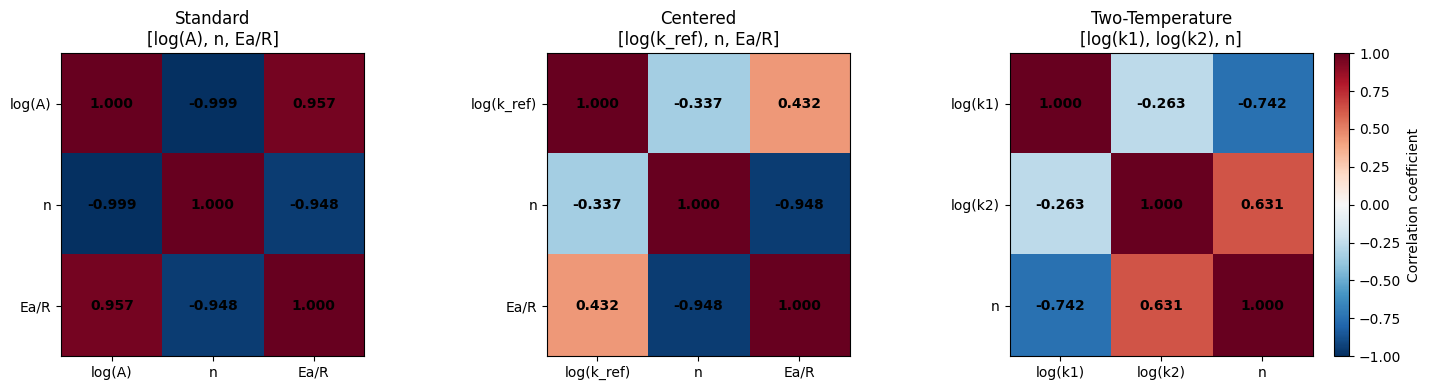


CONFIDENCE ELLIPSES COMPARISON (Ea/R METHODS)

Plotting confidence ellipses for Standard [log(A), n, Ea/R]...


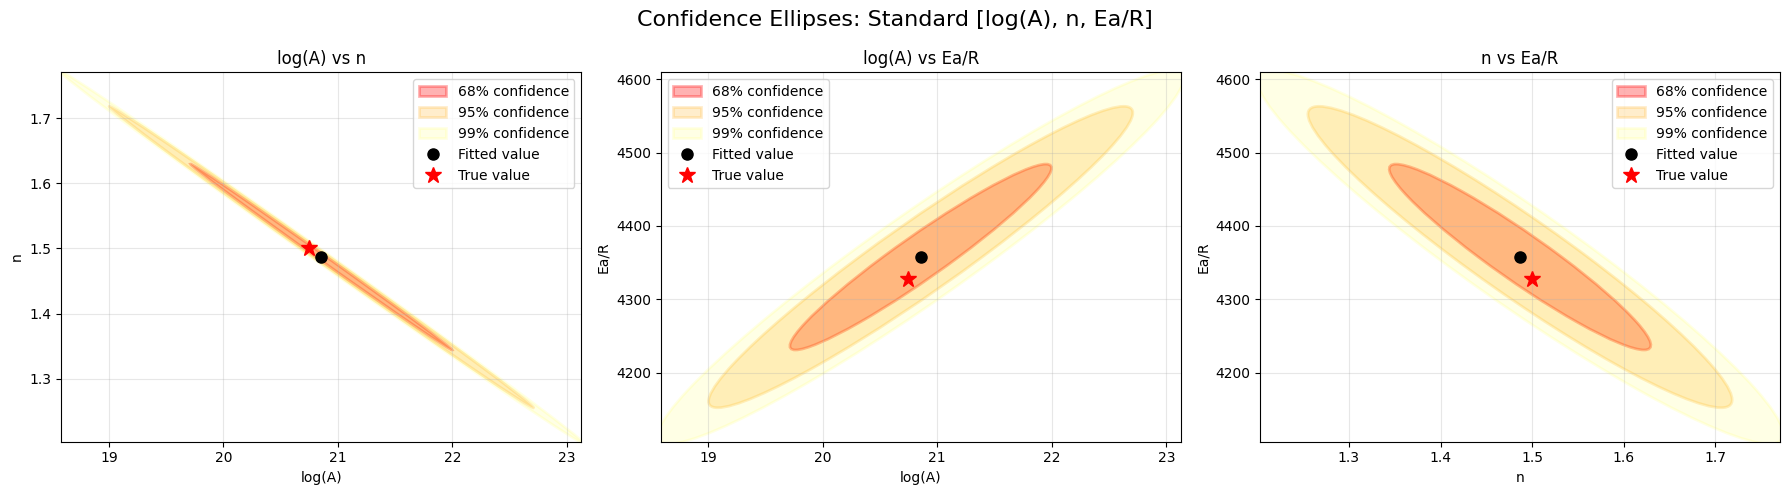


Plotting confidence ellipses for Centered [log(k_ref), n, Ea/R]...


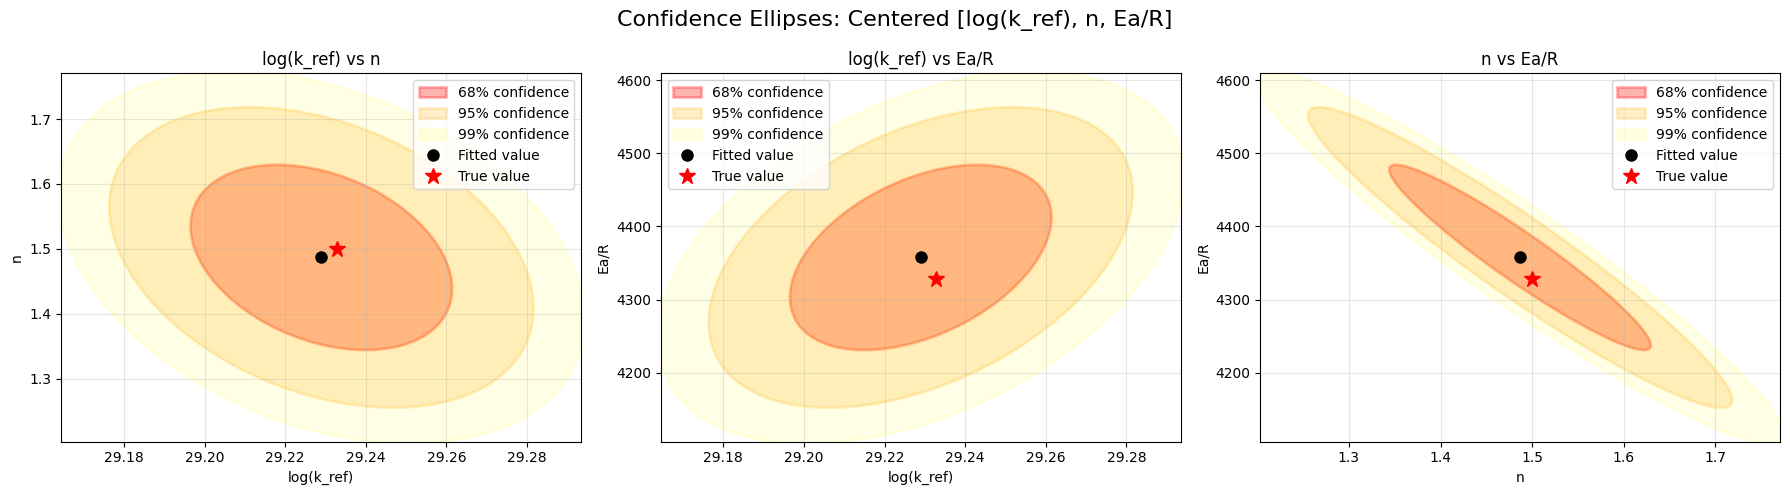


Plotting confidence ellipses for Two-Temperature [log(k1), log(k2), n]...


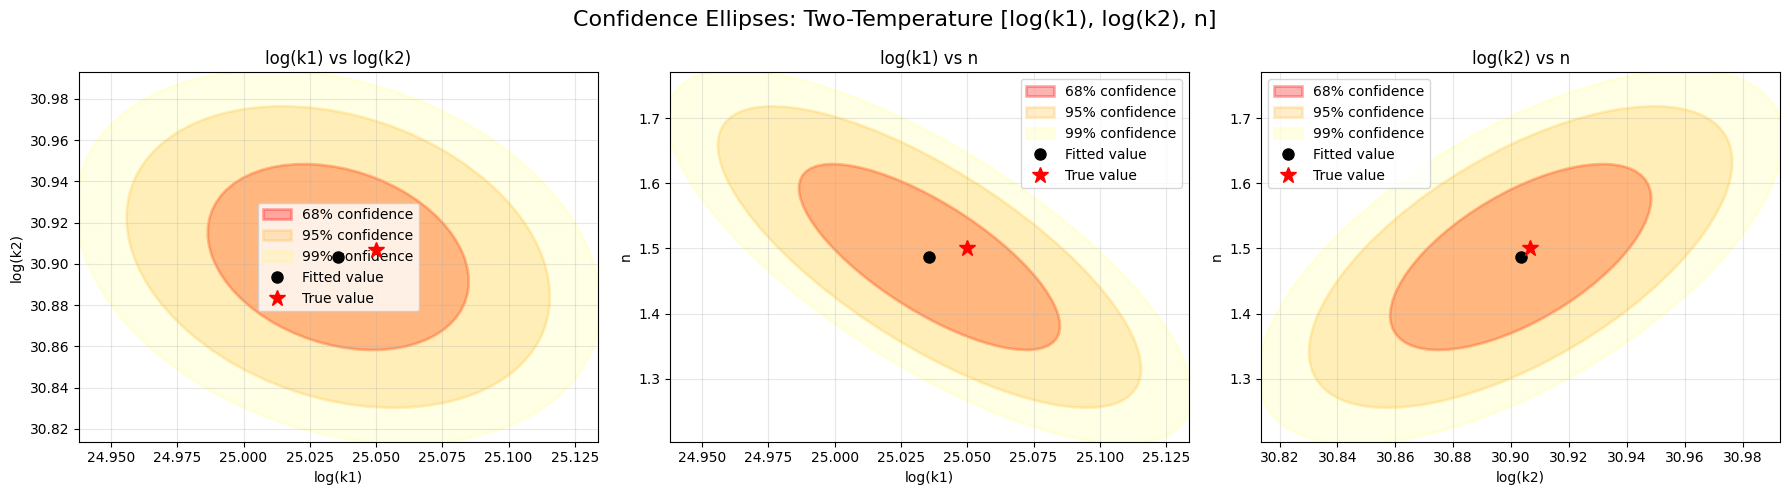


FITTING RESULTS COMPARISON (Ea/R METHODS)


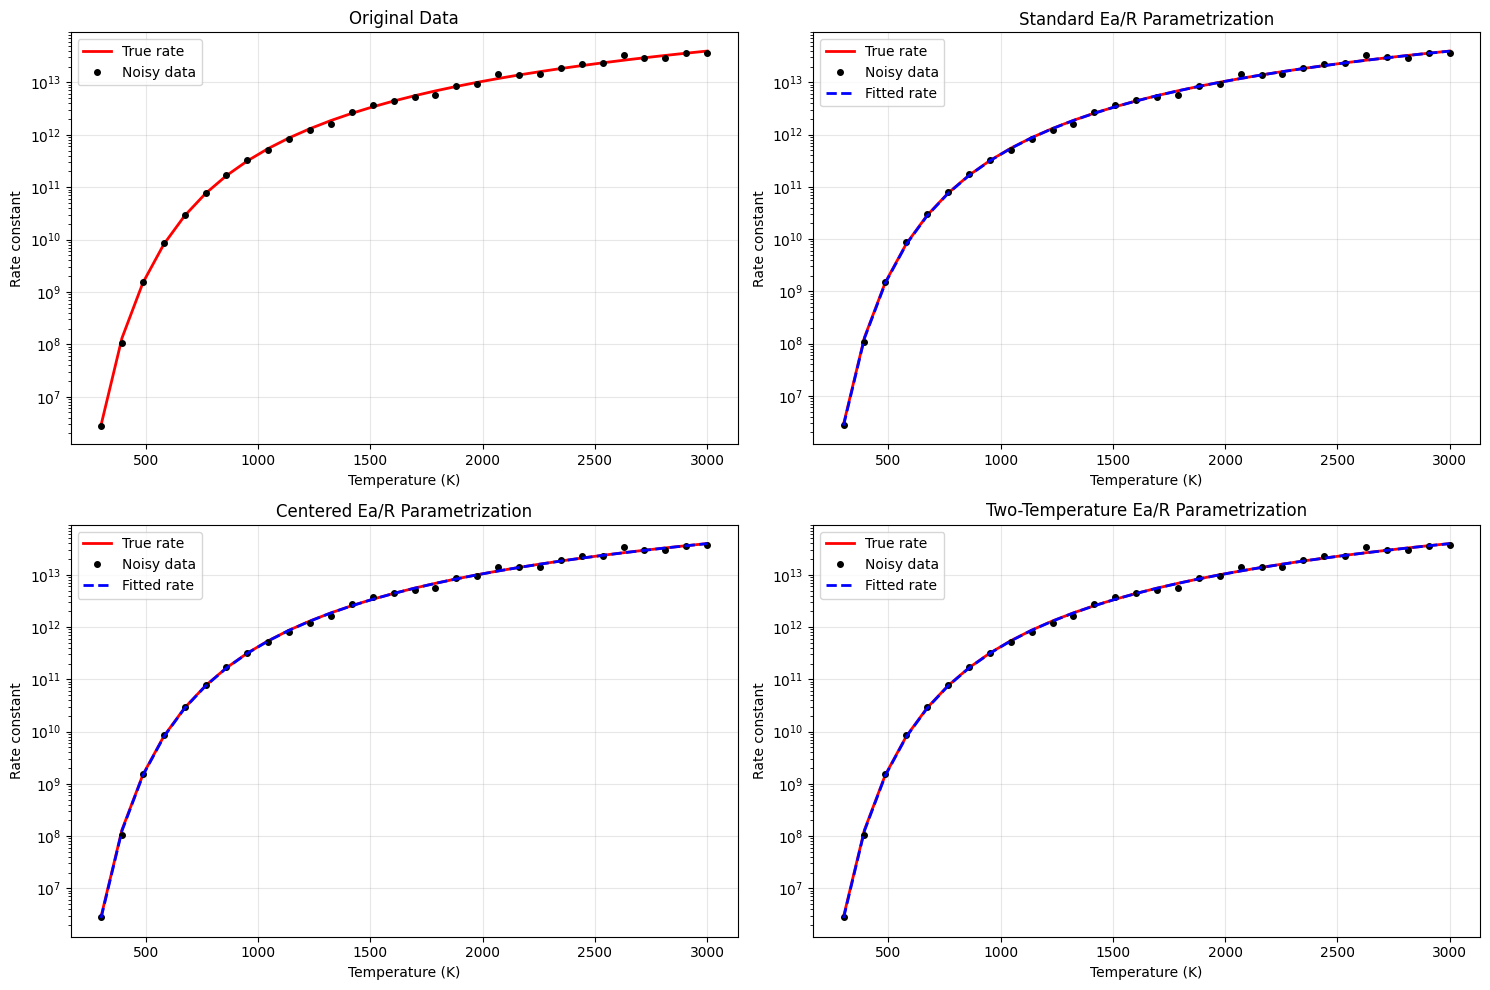

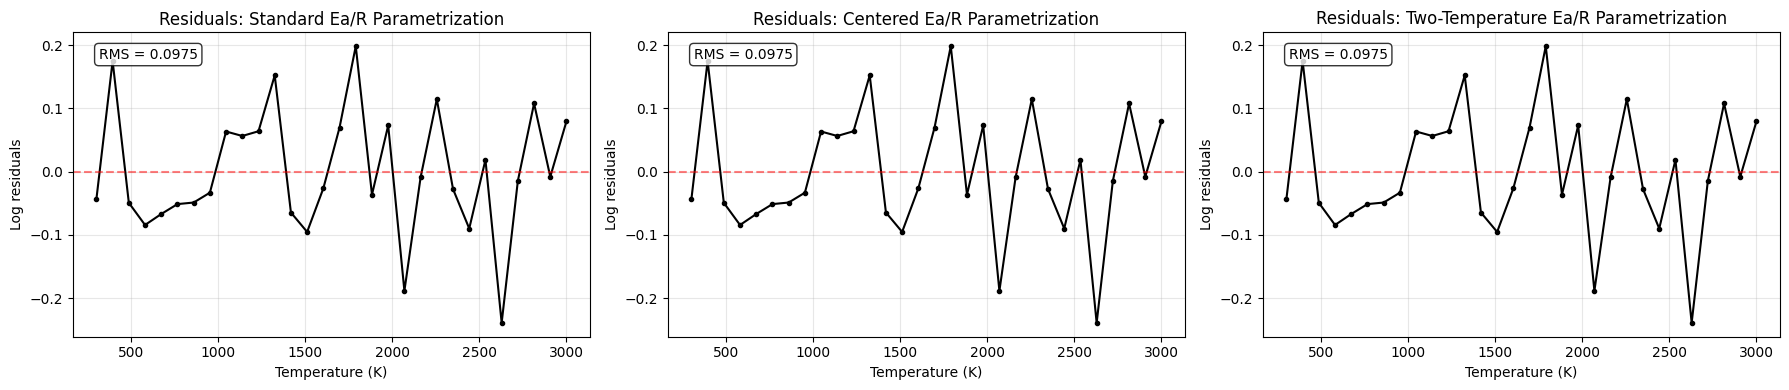


3D CONFIDENCE REGIONS COMPARISON (Ea/R METHODS)


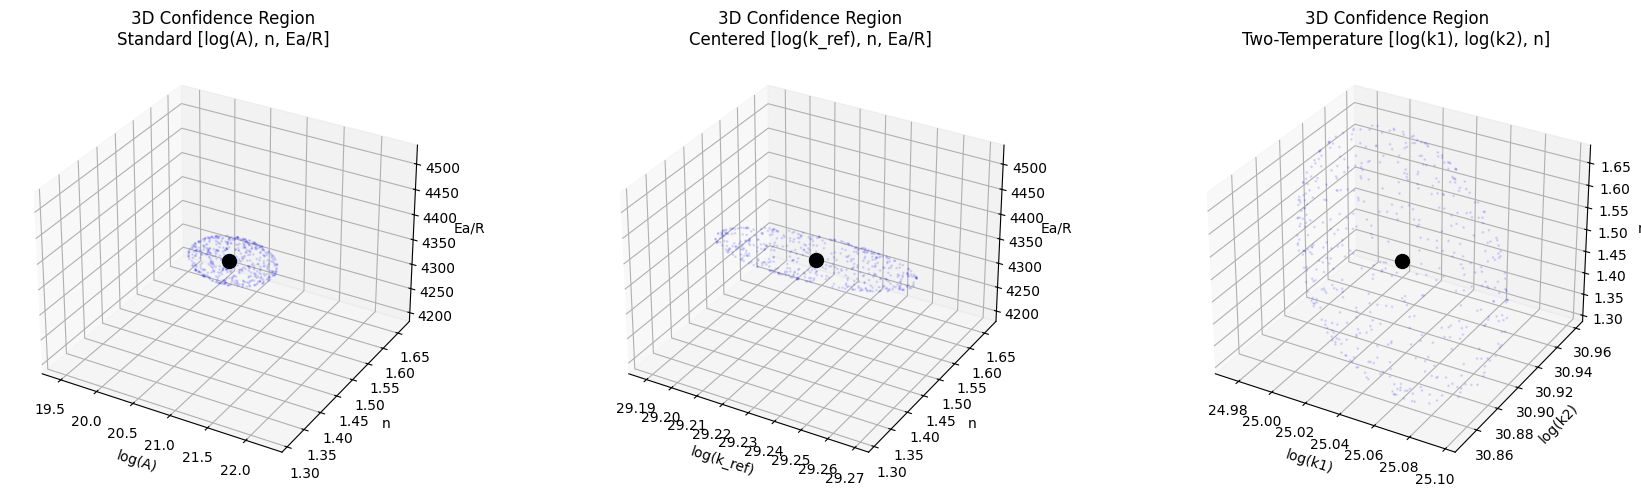


DETAILED PARAMETER ESTIMATES AND UNCERTAINTIES (Ea/R PARAMETRIZATION)

EA-R-STANDARD PARAMETRIZATION:
--------------------------------------------------
Fitted parameters:
  A:    1.141e+09  (true: 1.020e+09, error: 11.8%)
  n:    1.487  (true: 1.500, error: 0.9%)
  Ea:   8658.6 cal/mol  (true: 8600.0 cal/mol, error: 0.7%)
  Ea/R: 4357.6 K  (true: 4328.1 K, error: 0.7%)

Parameter uncertainties:
  A:    ±8.634e+08 (75.7%)
  n:    ±0.095 (6.4%)
  Ea/R: ±83.9 K (1.9%)
  Ea:   ±166.7 cal/mol (1.9%)

Residual standard deviation: 0.1028
Maximum |correlation|: 0.999
Condition number: 1.08e+09+0.00e+00j
  ⚠️  High condition number - potential numerical issues

EA-R-CENTERED PARAMETRIZATION:
--------------------------------------------------
Fitted parameters:
  A:    1.141e+09  (true: 1.020e+09, error: 11.8%)
  n:    1.487  (true: 1.500, error: 0.9%)
  Ea:   8658.6 cal/mol  (true: 8600.0 cal/mol, error: 0.7%)
  Ea/R: 4357.6 K  (true: 4328.1 K, error: 0.7%)

Parameter uncertainties (native pa

In [18]:
import jax.numpy as jnp
import jax
import optimistix as optx
import matplotlib.pyplot as plt

def arrhenius_rate_constant_ea_r(T, A, n, Ea_over_R):
    """Arrhenius equation with Ea/R as parameter: k = A * T^n * exp(-Ea_over_R/T)"""
    return A * jnp.power(T, n) * jnp.exp(-Ea_over_R / T)

def arrhenius_centered_ea_r(T, k_ref, T_ref, n, Ea_over_R):
    """Centered reparametrization with Ea/R: k = k_ref * (T/T_ref)^n * exp(-Ea_over_R * (1/T - 1/T_ref))"""
    return k_ref * jnp.power(T / T_ref, n) * jnp.exp(-Ea_over_R * (1/T - 1/T_ref))

# Residual functions for Ea/R parametrization
def residual_fn_ea_r(params, args):
    """Standard Arrhenius with Ea/R: params = [log(A), n, Ea/R]"""
    T_data, k_data = args
    A = jnp.exp(params[0])
    n = params[1]
    Ea_over_R = params[2]
    k_pred = arrhenius_rate_constant_ea_r(T_data, A, n, Ea_over_R)
    return jnp.log(k_pred) - jnp.log(k_data)

def residual_fn_centered_ea_r(params, args):
    """Centered Arrhenius with Ea/R: params = [log(k_ref), n, Ea/R]"""
    T_data, k_data, T_ref = args
    log_k_ref = params[0]
    n = params[1]
    Ea_over_R = params[2]
    k_ref = jnp.exp(log_k_ref)
    k_pred = arrhenius_centered_ea_r(T_data, k_ref, T_ref, n, Ea_over_R)
    return jnp.log(k_pred) - jnp.log(k_data)

def residual_fn_two_temp_ea_r(params, args):
    """Two-temperature reparametrization with Ea/R: params = [log(k1), log(k2), n]"""
    T_data, k_data, T1, T2 = args
    log_k1 = params[0]
    log_k2 = params[1]
    n = params[2]
    
    # Derive Ea/R and A from k1, k2, T1, T2
    k1 = jnp.exp(log_k1)
    k2 = jnp.exp(log_k2)
    
    # Ea/R = ln(k1/k2 * (T2/T1)^n) / (1/T2 - 1/T1)
    Ea_over_R = jnp.log(k1/k2 * jnp.power(T2/T1, n)) / (1/T2 - 1/T1)
    # A = k1 / (T1^n * exp(-Ea_over_R/T1))
    A = k1 / (jnp.power(T1, n) * jnp.exp(-Ea_over_R / T1))
    
    k_pred = arrhenius_rate_constant_ea_r(T_data, A, n, Ea_over_R)
    return jnp.log(k_pred) - jnp.log(k_data)

def compare_ea_r_parametrizations(T, k_noisy):
    """Compare parametrizations using Ea/R instead of Ea"""
    
    results = {}
    
    # Choose reference temperatures
    T_ref = jnp.mean(T)
    T1, T2 = T[5], T[-5]
    
    print(f"Temperature range: {T.min():.0f} - {T.max():.0f} K")
    print(f"Reference temperature (T_ref): {T_ref:.0f} K")
    print("="*60)
    
    # Solver setup
    solver = optx.LevenbergMarquardt(rtol=1e-10, atol=1e-10)
    
    ## 1. Standard parametrization with Ea/R
    print("\n1. STANDARD PARAMETRIZATION [log(A), n, Ea/R]")
    # True Ea/R = 8600/1.987 ≈ 4329 K
    initial_guess_ea_r = jnp.array([jnp.log(1e9), 1.0, 4500.0])
    
    sol_ea_r = optx.least_squares(
        fn=residual_fn_ea_r,
        solver=solver,
        y0=initial_guess_ea_r,
        args=(T, k_noisy)
    )
    
    if sol_ea_r.result == optx.RESULTS.successful:
        A_ea_r = jnp.exp(sol_ea_r.value[0])
        n_ea_r = sol_ea_r.value[1]
        Ea_over_R_fitted = sol_ea_r.value[2]
        Ea_ea_r = Ea_over_R_fitted * 1.987  # Convert back to cal/mol
        
        print(f"A = {A_ea_r:.3e}, n = {n_ea_r:.3f}, Ea/R = {Ea_over_R_fitted:.1f} K")
        print(f"Equivalent Ea = {Ea_ea_r:.1f} cal/mol")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_ea_r)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(A)-n = {corr_matrix[0,1]:.3f}, log(A)-(Ea/R) = {corr_matrix[0,2]:.3f}, n-(Ea/R) = {corr_matrix[1,2]:.3f}")
        
        results['ea_r_standard'] = {
            'params': [A_ea_r, n_ea_r, Ea_ea_r],
            'params_native': [A_ea_r, n_ea_r, Ea_over_R_fitted],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_ea_r
        }
    
    ## 2. Centered parametrization with Ea/R
    print(f"\n2. CENTERED PARAMETRIZATION [log(k_ref@{T_ref:.0f}K), n, Ea/R]")
    
    # Estimate k_ref at T_ref from data
    idx_ref = jnp.argmin(jnp.abs(T - T_ref))
    k_ref_est = k_noisy[idx_ref]
    initial_guess_centered_ea_r = jnp.array([jnp.log(k_ref_est), 1.0, 4500.0])
    
    sol_centered_ea_r = optx.least_squares(
        fn=residual_fn_centered_ea_r,
        solver=solver,
        y0=initial_guess_centered_ea_r,
        args=(T, k_noisy, T_ref)
    )
    
    if sol_centered_ea_r.result == optx.RESULTS.successful:
        k_ref_fitted = jnp.exp(sol_centered_ea_r.value[0])
        n_centered_ea_r = sol_centered_ea_r.value[1]
        Ea_over_R_centered = sol_centered_ea_r.value[2]
        Ea_centered_ea_r = Ea_over_R_centered * 1.987
        
        # Convert back to standard A for comparison
        A_centered_ea_r = k_ref_fitted / (jnp.power(T_ref, n_centered_ea_r) * jnp.exp(-Ea_over_R_centered / T_ref))
        
        print(f"k_ref = {k_ref_fitted:.3e}, n = {n_centered_ea_r:.3f}, Ea/R = {Ea_over_R_centered:.1f} K")
        print(f"Equivalent A = {A_centered_ea_r:.3e}, Ea = {Ea_centered_ea_r:.1f} cal/mol")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_centered_ea_r)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(k_ref)-n = {corr_matrix[0,1]:.3f}, log(k_ref)-(Ea/R) = {corr_matrix[0,2]:.3f}, n-(Ea/R) = {corr_matrix[1,2]:.3f}")
        
        results['ea_r_centered'] = {
            'params': [A_centered_ea_r, n_centered_ea_r, Ea_centered_ea_r],
            'params_native': [k_ref_fitted, n_centered_ea_r, Ea_over_R_centered],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_centered_ea_r
        }
    
    ## 3. Two-temperature parametrization with Ea/R
    print(f"\n3. TWO-TEMPERATURE PARAMETRIZATION [log(k@{T1:.0f}K), log(k@{T2:.0f}K), n]")
    
    # Estimate k1 and k2 from data
    idx1 = jnp.argmin(jnp.abs(T - T1))
    idx2 = jnp.argmin(jnp.abs(T - T2))
    k1_est = k_noisy[idx1]
    k2_est = k_noisy[idx2]
    initial_guess_two_temp_ea_r = jnp.array([jnp.log(k1_est), jnp.log(k2_est), 1.0])
    
    sol_two_temp_ea_r = optx.least_squares(
        fn=residual_fn_two_temp_ea_r,
        solver=solver,
        y0=initial_guess_two_temp_ea_r,
        args=(T, k_noisy, T1, T2)
    )
    
    if sol_two_temp_ea_r.result == optx.RESULTS.successful:
        k1_fitted = jnp.exp(sol_two_temp_ea_r.value[0])
        k2_fitted = jnp.exp(sol_two_temp_ea_r.value[1])
        n_two_temp_ea_r = sol_two_temp_ea_r.value[2]
        
        # Convert to standard A, n, Ea
        Ea_over_R_two_temp = jnp.log(k1_fitted/k2_fitted * jnp.power(T2/T1, n_two_temp_ea_r)) / (1/T2 - 1/T1)
        A_two_temp_ea_r = k1_fitted / (jnp.power(T1, n_two_temp_ea_r) * jnp.exp(-Ea_over_R_two_temp / T1))
        Ea_two_temp_ea_r = Ea_over_R_two_temp * 1.987
        
        print(f"k1 = {k1_fitted:.3e}, k2 = {k2_fitted:.3e}, n = {n_two_temp_ea_r:.3f}")
        print(f"Equivalent A = {A_two_temp_ea_r:.3e}, Ea/R = {Ea_over_R_two_temp:.1f} K, Ea = {Ea_two_temp_ea_r:.1f} cal/mol")
        
        # Compute correlations
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol_two_temp_ea_r)
        if cov_matrix is not None:
            std_matrix = jnp.outer(std_errors, std_errors)
            corr_matrix = cov_matrix / std_matrix
            print(f"Correlations: log(k1)-log(k2) = {corr_matrix[0,1]:.3f}, log(k1)-n = {corr_matrix[0,2]:.3f}, log(k2)-n = {corr_matrix[1,2]:.3f}")
        
        results['ea_r_two_temp'] = {
            'params': [A_two_temp_ea_r, n_two_temp_ea_r, Ea_two_temp_ea_r],
            'params_native': [k1_fitted, k2_fitted, n_two_temp_ea_r],
            'correlation': corr_matrix if cov_matrix is not None else None,
            'solution': sol_two_temp_ea_r
        }
    
    return results

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """Compute parameter uncertainties accounting for residual variance."""
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
    else:
        # For FunctionLinearOperator, evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular")
        return None, None, residual_variance

def plot_ea_r_correlation_comparison(results_ea, results_ea_r):
    """Compare correlation matrices between Ea and Ea/R parametrizations"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    method_names = {
        'standard': 'Standard',
        'centered': 'Centered', 
        'two_temp': 'Two-Temperature'
    }
    
    param_labels_ea = {
        'standard': ['log(A)', 'n', 'Ea'],
        'centered': ['log(k_ref)', 'n', 'Ea'],
        'two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    param_labels_ea_r = {
        'ea_r_standard': ['log(A)', 'n', 'Ea/R'],
        'ea_r_centered': ['log(k_ref)', 'n', 'Ea/R'],
        'ea_r_two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    # Plot Ea parametrizations (top row)
    for idx, (method, data) in enumerate(results_ea.items()):
        if data['correlation'] is not None and idx < 3:
            corr_matrix = data['correlation']
            
            im = axes[0, idx].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
            
            # Add text annotations
            for i in range(3):
                for j in range(3):
                    text = axes[0, idx].text(j, i, f'{corr_matrix[i, j]:.3f}',
                                        ha="center", va="center", color="black", fontweight='bold')
            
            axes[0, idx].set_xticks(range(3))
            axes[0, idx].set_yticks(range(3))
            axes[0, idx].set_xticklabels(param_labels_ea[method])
            axes[0, idx].set_yticklabels(param_labels_ea[method])
            axes[0, idx].set_title(f'{method_names[method]}\n(Ea parametrization)')
    
    # Plot Ea/R parametrizations (bottom row)
    for idx, (method, data) in enumerate(results_ea_r.items()):
        if data['correlation'] is not None and idx < 3:
            corr_matrix = data['correlation']
            
            im = axes[1, idx].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
            
            # Add text annotations
            for i in range(3):
                for j in range(3):
                    text = axes[1, idx].text(j, i, f'{corr_matrix[i, j]:.3f}',
                                        ha="center", va="center", color="black", fontweight='bold')
            
            axes[1, idx].set_xticks(range(3))
            axes[1, idx].set_yticks(range(3))
            axes[1, idx].set_xticklabels(param_labels_ea_r[method])
            axes[1, idx].set_yticklabels(param_labels_ea_r[method])
            axes[1, idx].set_title(f'{method_names[method.replace("ea_r_", "")]}\n(Ea/R parametrization)')
    
    # Add colorbar
    plt.colorbar(im, ax=axes.ravel().tolist(), label='Correlation coefficient')
    
    plt.tight_layout()
    plt.show()

def plot_confidence_ellipses_ea_r(results, T, k_noisy):
    """Plot confidence ellipses for Ea/R parametrization methods"""
    
    from matplotlib.patches import Ellipse
    import numpy as np
    from scipy.stats import chi2
    
    method_names = {
        'ea_r_standard': 'Standard [log(A), n, Ea/R]',
        'ea_r_centered': 'Centered [log(k_ref), n, Ea/R]', 
        'ea_r_two_temp': 'Two-Temperature [log(k1), log(k2), n]'
    }
    
    param_labels = {
        'ea_r_standard': ['log(A)', 'n', 'Ea/R'],
        'ea_r_centered': ['log(k_ref)', 'n', 'Ea/R'],
        'ea_r_two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    # True values for comparison
    true_values_dict = {
        'ea_r_standard': [jnp.log(1.020e9), 1.500, 8600.0/1.987],
        'ea_r_centered': None,  # Will compute
        'ea_r_two_temp': None   # Will compute
    }
    
    # Compute true values for centered and two-temp parametrizations
    if 'ea_r_centered' in results:
        T_ref = jnp.mean(T)
        true_k_ref = 1.020e9 * jnp.power(T_ref, 1.5) * jnp.exp(-8600.0/1.987 / T_ref)
        true_values_dict['ea_r_centered'] = [jnp.log(true_k_ref), 1.500, 8600.0/1.987]
    
    if 'ea_r_two_temp' in results:
        T1, T2 = T[5], T[-5]
        true_k1 = 1.020e9 * jnp.power(T1, 1.5) * jnp.exp(-8600.0/1.987 / T1)
        true_k2 = 1.020e9 * jnp.power(T2, 1.5) * jnp.exp(-8600.0/1.987 / T2)
        true_values_dict['ea_r_two_temp'] = [jnp.log(true_k1), jnp.log(true_k2), 1.500]
    
    # Plot for each method
    for method, data in results.items():
        if data['correlation'] is None:
            continue
            
        print(f"\nPlotting confidence ellipses for {method_names[method]}...")
        
        fitted_params = np.array(data['solution'].value)
        cov_np = np.array(data['correlation'])
        true_values = true_values_dict[method]
        
        # Convert correlation to covariance
        std_errors, _, _ = compute_parameter_uncertainty_with_noise(data['solution'])
        if std_errors is None:
            continue
        std_errors_np = np.array(std_errors)
        cov_np = cov_np * np.outer(std_errors_np, std_errors_np)
        
        # Confidence levels
        confidence_levels = [0.68, 0.95, 0.99]
        colors = ['red', 'orange', 'yellow']
        alphas = [0.3, 0.2, 0.1]
        
        # Parameter pairs
        param_pairs = [(0, 1), (0, 2), (1, 2)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for idx, (i, j) in enumerate(param_pairs):
            ax = axes[idx]
            
            # Extract 2x2 covariance submatrix
            cov_2d = cov_np[np.ix_([i, j], [i, j])]
            
            # Eigenvalues and eigenvectors for ellipse orientation
            eigenvals, eigenvecs = np.linalg.eigh(cov_2d)
            
            # Sort by eigenvalue
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            
            # Angle of first eigenvector
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            
            # Plot confidence ellipses
            for conf_level, color, alpha in zip(confidence_levels, colors, alphas):
                chi2_val = chi2.ppf(conf_level, df=2)
                
                width = 2 * np.sqrt(chi2_val * eigenvals[0])
                height = 2 * np.sqrt(chi2_val * eigenvals[1])
                
                ellipse = Ellipse(
                    xy=(fitted_params[i], fitted_params[j]),
                    width=width,
                    height=height,
                    angle=angle,
                    facecolor=color,
                    alpha=alpha,
                    edgecolor=color,
                    linewidth=2,
                    label=f'{conf_level*100:.0f}% confidence'
                )
                ax.add_patch(ellipse)
            
            # Plot fitted and true points
            ax.plot(fitted_params[i], fitted_params[j], 'ko', markersize=8, 
                   label='Fitted value', zorder=10)
            
            if true_values:
                ax.plot(true_values[i], true_values[j], 'r*', markersize=12, 
                       label='True value', zorder=10)
            
            # Labels and formatting
            ax.set_xlabel(param_labels[method][i])
            ax.set_ylabel(param_labels[method][j])
            ax.set_title(f'{param_labels[method][i]} vs {param_labels[method][j]}')
            ax.grid(True, alpha=0.3)
            ax.legend()
            
            # Set axis limits
            center_x, center_y = fitted_params[i], fitted_params[j]
            max_std_x = 3 * np.sqrt(cov_2d[0, 0])
            max_std_y = 3 * np.sqrt(cov_2d[1, 1])
            
            ax.set_xlim(center_x - max_std_x, center_x + max_std_x)
            ax.set_ylim(center_y - max_std_y, center_y + max_std_y)
        
        plt.suptitle(f'Confidence Ellipses: {method_names[method]}', fontsize=16)
        plt.tight_layout()
        plt.show()

def plot_fitting_comparison_ea_r(results, T, k_true, k_noisy):
    """Plot fitting results for Ea/R methods"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    method_names = {
        'ea_r_standard': 'Standard Ea/R Parametrization',
        'ea_r_centered': 'Centered Ea/R Parametrization',
        'ea_r_two_temp': 'Two-Temperature Ea/R Parametrization'
    }
    
    # Plot original data in first subplot
    axes[0].semilogy(T, k_true, "r-", linewidth=2, label="True rate")
    axes[0].semilogy(T, k_noisy, "ko", markersize=4, label="Noisy data")
    axes[0].set_xlabel("Temperature (K)")
    axes[0].set_ylabel("Rate constant")
    axes[0].set_title("Original Data")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot fits for each method
    plot_idx = 1
    for method, data in results.items():
        if plot_idx > 3:
            break
            
        ax = axes[plot_idx]
        
        # Reconstruct fitted rate constants
        A_fit, n_fit, Ea_fit = data['params']
        k_fitted = arrhenius_rate_constant_ea_r(T, A_fit, n_fit, Ea_fit/1.987)  # Convert back to Ea/R
        
        # Calculate residuals
        residuals = jnp.log(k_fitted) - jnp.log(k_noisy)
        
        # Main plot
        ax.semilogy(T, k_true, "r-", linewidth=2, label="True rate")
        ax.semilogy(T, k_noisy, "ko", markersize=4, label="Noisy data")
        ax.semilogy(T, k_fitted, "b--", linewidth=2, label="Fitted rate")
        
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("Rate constant")
        ax.set_title(method_names[method])
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    # Remove unused subplot
    if len(results) < 3:
        axes[3].remove()
    
    plt.tight_layout()
    plt.show()
    
    # Plot residuals comparison
    fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 4))
    if len(results) == 1:
        axes = [axes]
    
    for idx, (method, data) in enumerate(results.items()):
        A_fit, n_fit, Ea_fit = data['params']
        k_fitted = arrhenius_rate_constant_ea_r(T, A_fit, n_fit, Ea_fit/1.987)
        residuals = jnp.log(k_fitted) - jnp.log(k_noisy)
        
        axes[idx].plot(T, residuals, "ko-", markersize=3)
        axes[idx].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[idx].set_xlabel("Temperature (K)")
        axes[idx].set_ylabel("Log residuals")
        axes[idx].set_title(f"Residuals: {method_names[method]}")
        axes[idx].grid(True, alpha=0.3)
        
        # Add RMS residual
        rms_residual = jnp.sqrt(jnp.mean(residuals**2))
        axes[idx].text(0.05, 0.95, f'RMS = {rms_residual:.4f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def plot_3d_confidence_regions_ea_r(results):
    """Plot 3D confidence regions for Ea/R parametrization comparison"""
    
    from mpl_toolkits.mplot3d import Axes3D
    from scipy.stats import chi2
    import numpy as np
    
    method_names = {
        'ea_r_standard': 'Standard [log(A), n, Ea/R]',
        'ea_r_centered': 'Centered [log(k_ref), n, Ea/R]', 
        'ea_r_two_temp': 'Two-Temperature [log(k1), log(k2), n]'
    }
    
    param_labels = {
        'ea_r_standard': ['log(A)', 'n', 'Ea/R'],
        'ea_r_centered': ['log(k_ref)', 'n', 'Ea/R'],
        'ea_r_two_temp': ['log(k1)', 'log(k2)', 'n']
    }
    
    n_methods = len(results)
    fig = plt.figure(figsize=(6*n_methods, 5))
    
    for idx, (method, data) in enumerate(results.items()):
        if data['correlation'] is None:
            continue
            
        ax = fig.add_subplot(1, n_methods, idx+1, projection='3d')
        
        fitted_params = np.array(data['solution'].value)
        
        # Get covariance matrix
        std_errors, _, _ = compute_parameter_uncertainty_with_noise(data['solution'])
        if std_errors is None:
            continue
            
        corr_matrix = data['correlation']
        std_errors_np = np.array(std_errors)
        cov_np = corr_matrix * np.outer(std_errors_np, std_errors_np)
        
        # Generate confidence ellipsoid (68% level)
        chi2_val_3d = chi2.ppf(0.68, df=3)
        
        # Sample points on unit sphere
        n_points = 500
        phi = np.random.uniform(0, 2*np.pi, n_points)
        costheta = np.random.uniform(-1, 1, n_points)
        theta = np.arccos(costheta)
        
        x_sphere = np.sin(theta) * np.cos(phi)
        y_sphere = np.sin(theta) * np.sin(phi)
        z_sphere = np.cos(theta)
        
        sphere_points = np.column_stack([x_sphere, y_sphere, z_sphere])
        
        # Transform to ellipsoid
        try:
            L = np.linalg.cholesky(cov_np)
            ellipsoid_points = fitted_params + np.sqrt(chi2_val_3d) * (sphere_points @ L.T)
            
            # Plot confidence region
            ax.scatter(ellipsoid_points[:, 0], ellipsoid_points[:, 1], ellipsoid_points[:, 2], 
                      alpha=0.1, s=1, c='blue')
            
            # Plot fitted point
            ax.scatter(fitted_params[0], fitted_params[1], fitted_params[2], 
                      c='black', s=100, label='Fitted value')
            
            ax.set_xlabel(param_labels[method][0])
            ax.set_ylabel(param_labels[method][1])
            ax.set_zlabel(param_labels[method][2])
            ax.set_title(f'3D Confidence Region\n{method_names[method]}')
            
        except np.linalg.LinAlgError:
            ax.text(0.5, 0.5, 0.5, 'Singular covariance\nmatrix', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{method_names[method]}\n(Singular)')
    
    plt.tight_layout()
    plt.show()

def print_detailed_results_ea_r(results):
    """Print detailed parameter estimates and uncertainties for Ea/R methods"""
    
    print(f"\n" + "="*80)
    print("DETAILED PARAMETER ESTIMATES AND UNCERTAINTIES (Ea/R PARAMETRIZATION)")
    print("="*80)
    
    true_params = [1.020e9, 1.500, 8600.0]
    true_ea_over_r = 8600.0 / 1.987
    
    for method, data in results.items():
        print(f"\n{method.upper().replace('_', '-')} PARAMETRIZATION:")
        print("-" * 50)
        
        A_fit, n_fit, Ea_fit = data['params']
        Ea_over_R_fit = Ea_fit / 1.987
        
        # Calculate relative errors
        rel_error_A = abs(A_fit - true_params[0]) / true_params[0] * 100
        rel_error_n = abs(n_fit - true_params[1]) / true_params[1] * 100
        rel_error_Ea = abs(Ea_fit - true_params[2]) / true_params[2] * 100
        rel_error_Ea_R = abs(Ea_over_R_fit - true_ea_over_r) / true_ea_over_r * 100
        
        print(f"Fitted parameters:")
        print(f"  A:    {A_fit:.3e}  (true: {true_params[0]:.3e}, error: {rel_error_A:.1f}%)")
        print(f"  n:    {n_fit:.3f}  (true: {true_params[1]:.3f}, error: {rel_error_n:.1f}%)")
        print(f"  Ea:   {Ea_fit:.1f} cal/mol  (true: {true_params[2]:.1f} cal/mol, error: {rel_error_Ea:.1f}%)")
        print(f"  Ea/R: {Ea_over_R_fit:.1f} K  (true: {true_ea_over_r:.1f} K, error: {rel_error_Ea_R:.1f}%)")
        
        # Compute uncertainties
        std_errors, cov_matrix, residual_variance = compute_parameter_uncertainty_with_noise(data['solution'])
        
        if std_errors is not None:
            if 'standard' in method:
                A_std = A_fit * std_errors[0]  # Convert from log-space
                print(f"\nParameter uncertainties:")
                print(f"  A:    ±{A_std:.3e} ({A_std/A_fit*100:.1f}%)")
                print(f"  n:    ±{std_errors[1]:.3f} ({std_errors[1]/n_fit*100:.1f}%)")
                print(f"  Ea/R: ±{std_errors[2]:.1f} K ({std_errors[2]/Ea_over_R_fit*100:.1f}%)")
                print(f"  Ea:   ±{std_errors[2]*1.987:.1f} cal/mol ({std_errors[2]*1.987/Ea_fit*100:.1f}%)")
            else:
                # For other methods, show uncertainties in their native parametrization
                print(f"\nParameter uncertainties (native parametrization):")
                for i, param_std in enumerate(std_errors):
                    print(f"  θ_{i}: ±{param_std:.3e}")
                    
            print(f"\nResidual standard deviation: {jnp.sqrt(residual_variance):.4f}")
            
            # Correlation analysis
            if cov_matrix is not None:
                corr_matrix = data['correlation']
                max_corr = jnp.max(jnp.abs(corr_matrix - jnp.eye(3)))
                print(f"Maximum |correlation|: {max_corr:.3f}")
                
                # Condition number
                eigenvals = jnp.linalg.eigvals(cov_matrix)
                condition_number = jnp.max(eigenvals) / jnp.min(eigenvals)
                print(f"Condition number: {condition_number:.2e}")
                
                if condition_number > 1e12:
                    print("  ⚠️  Very high condition number - near singular covariance")
                elif condition_number > 1e6:
                    print("  ⚠️  High condition number - potential numerical issues")
                else:
                    print("  ✓  Good numerical conditioning")

def print_ea_r_comparison_summary(results_ea, results_ea_r):
    """Print a summary comparing Ea vs Ea/R parametrizations"""
    
    print(f"\n" + "="*80)
    print("COMPARISON: Ea vs Ea/R PARAMETRIZATIONS")
    print("="*80)
    
    true_params = [1.020e9, 1.500, 8600.0]
    true_ea_over_r = 8600.0 / 1.987  # ≈ 4329 K
    
    print(f"True parameters: A = 1.020e9, n = 1.500, Ea = 8600.0 cal/mol, Ea/R = {true_ea_over_r:.1f} K\n")
    
    method_mapping = {
        'standard': 'ea_r_standard',
        'centered': 'ea_r_centered', 
        'two_temp': 'ea_r_two_temp'
    }
    
    for ea_method, ea_r_method in method_mapping.items():
        if ea_method in results_ea and ea_r_method in results_ea_r:
            print(f"{ea_method.upper().replace('_', '-')} PARAMETRIZATION:")
            print("-" * 50)
            
            # Ea results
            ea_data = results_ea[ea_method]
            A_ea, n_ea, Ea_ea = ea_data['params']
            
            # Ea/R results  
            ea_r_data = results_ea_r[ea_r_method]
            A_ea_r, n_ea_r, Ea_ea_r = ea_r_data['params']
            
            print(f"Ea parametrization:")
            print(f"  A = {A_ea:.3e}, n = {n_ea:.3f}, Ea = {Ea_ea:.1f}")
            
            print(f"Ea/R parametrization:")
            print(f"  A = {A_ea_r:.3e}, n = {n_ea_r:.3f}, Ea = {Ea_ea_r:.1f}")
            print(f"  (Ea/R = {Ea_ea_r/1.987:.1f} K)")
            
            # Compare correlations
            if ea_data['correlation'] is not None and ea_r_data['correlation'] is not None:
                max_corr_ea = jnp.max(jnp.abs(ea_data['correlation'] - jnp.eye(3)))
                max_corr_ea_r = jnp.max(jnp.abs(ea_r_data['correlation'] - jnp.eye(3)))
                
                print(f"\nMax |correlation|:")
                print(f"  Ea parametrization:   {max_corr_ea:.3f}")
                print(f"  Ea/R parametrization: {max_corr_ea_r:.3f}")
                
                if max_corr_ea_r < max_corr_ea:
                    print(f"  ✓ Ea/R reduces correlation by {((max_corr_ea - max_corr_ea_r)/max_corr_ea*100):.1f}%")
                else:
                    print(f"  → Ea/R increases correlation by {((max_corr_ea_r - max_corr_ea)/max_corr_ea*100):.1f}%")
            
            print()

# Example usage - you'll need to provide your own data or mock Arrhenius class
class MockArrhenius:
    def __init__(self, name, parameters):
        self.name = name
        self.A = parameters["A"]
        self.n = parameters["n"] 
        self.Ea = parameters["Ea"]
        
    def rate_constant(self, T):
        R = 1.987
        return self.A * jnp.power(T, self.n) * jnp.exp(-self.Ea / (R * T))

# Generate synthetic data
reaction_true = MockArrhenius(
    name="O+CH4<=>OH+CH3", 
    parameters={"A": 1.020e9, "n": 1.500, "Ea": 8600.0}
)
T = jnp.linspace(300, 3000, 30)
k_true = reaction_true.rate_constant(T)

# Add noise
noise_level = 0.1
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=T.shape) * noise_level
k_noisy = k_true * jnp.exp(noise)

print("COMPARING Ea vs Ea/R PARAMETRIZATIONS")
print("=" * 60)

# Compare Ea/R parametrizations
results_ea_r = compare_ea_r_parametrizations(T, k_noisy)

# Plot correlation comparison for Ea/R methods
print(f"\n" + "="*60)
print("CORRELATION MATRIX COMPARISON (Ea/R METHODS)")
fig, axes = plt.subplots(1, len(results_ea_r), figsize=(5*len(results_ea_r), 4))
if len(results_ea_r) == 1:
    axes = [axes]

method_names = {
    'ea_r_standard': 'Standard\n[log(A), n, Ea/R]',
    'ea_r_centered': 'Centered\n[log(k_ref), n, Ea/R]', 
    'ea_r_two_temp': 'Two-Temperature\n[log(k1), log(k2), n]'
}

param_labels = {
    'ea_r_standard': ['log(A)', 'n', 'Ea/R'],
    'ea_r_centered': ['log(k_ref)', 'n', 'Ea/R'],
    'ea_r_two_temp': ['log(k1)', 'log(k2)', 'n']
}

for idx, (method, data) in enumerate(results_ea_r.items()):
    if data['correlation'] is not None:
        corr_matrix = data['correlation']
        
        im = axes[idx].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
        
        # Add text annotations
        for i in range(3):
            for j in range(3):
                text = axes[idx].text(j, i, f'{corr_matrix[i, j]:.3f}',
                                    ha="center", va="center", color="black", fontweight='bold')
        
        axes[idx].set_xticks(range(3))
        axes[idx].set_yticks(range(3))
        axes[idx].set_xticklabels(param_labels[method])
        axes[idx].set_yticklabels(param_labels[method])
        axes[idx].set_title(method_names[method])
        
        # Add colorbar to last subplot
        if idx == len(results_ea_r) - 1:
            plt.colorbar(im, ax=axes[idx], label='Correlation coefficient')

plt.tight_layout()
plt.show()

# Plot confidence ellipses for Ea/R methods
print(f"\n" + "="*60)
print("CONFIDENCE ELLIPSES COMPARISON (Ea/R METHODS)")
plot_confidence_ellipses_ea_r(results_ea_r, T, k_noisy)

# Plot fitting comparison for Ea/R methods
print(f"\n" + "="*60)
print("FITTING RESULTS COMPARISON (Ea/R METHODS)")
plot_fitting_comparison_ea_r(results_ea_r, T, k_true, k_noisy)

# Plot 3D confidence regions for Ea/R methods
print(f"\n" + "="*60)
print("3D CONFIDENCE REGIONS COMPARISON (Ea/R METHODS)")
plot_3d_confidence_regions_ea_r(results_ea_r)

# Print detailed results for Ea/R methods
print_detailed_results_ea_r(results_ea_r)

# Summary for Ea/R methods
print(f"\n" + "="*60)
print("SUMMARY (Ea/R PARAMETRIZATIONS):")
print("-" * 30)
for method, data in results_ea_r.items():
    if data['correlation'] is not None:
        corr = data['correlation']
        max_corr = jnp.max(jnp.abs(corr - jnp.eye(3)))  # Max off-diagonal correlation
        print(f"{method:15}: Max |correlation| = {max_corr:.3f}")
    else:
        print(f"{method:15}: Failed to compute correlations")

# For direct comparison with original Ea parametrization, you would also run:
print(f"\n" + "="*60)
print("TO COMPARE WITH ORIGINAL Ea PARAMETRIZATION:")
print("Run your original compare_reparametrizations(T, k_noisy) function")
print("and then use plot_ea_r_correlation_comparison(results_ea, results_ea_r)")
print("to see side-by-side correlation matrix comparisons.")

DEMONSTRATION: OPTIMAL T_ref vs STANDARD CHOICES
COMPARISON OF T_ref SELECTION STRATEGIES

HEURISTIC STRATEGIES:
----------------------------------------
arithmetic_mean: T_ref = 1650.0 K, max_corr = 0.9476
geometric_mean : T_ref =  948.7 K, max_corr = 0.9476
median         : T_ref = 1650.0 K, max_corr = 0.9476
log_mean       : T_ref = 1405.1 K, max_corr = 0.9476

OPTIMIZED STRATEGIES:
----------------------------------------
Optimizing T_ref using objective: max_correlation
Search bounds: [570.0, 2730.0] K
Full temperature range: [300.0, 3000.0] K
Error in objective function evaluation at T_ref=1703.1697388461696: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/homebrew/Caskroom/miniconda/base/envs/plog/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
    ~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/

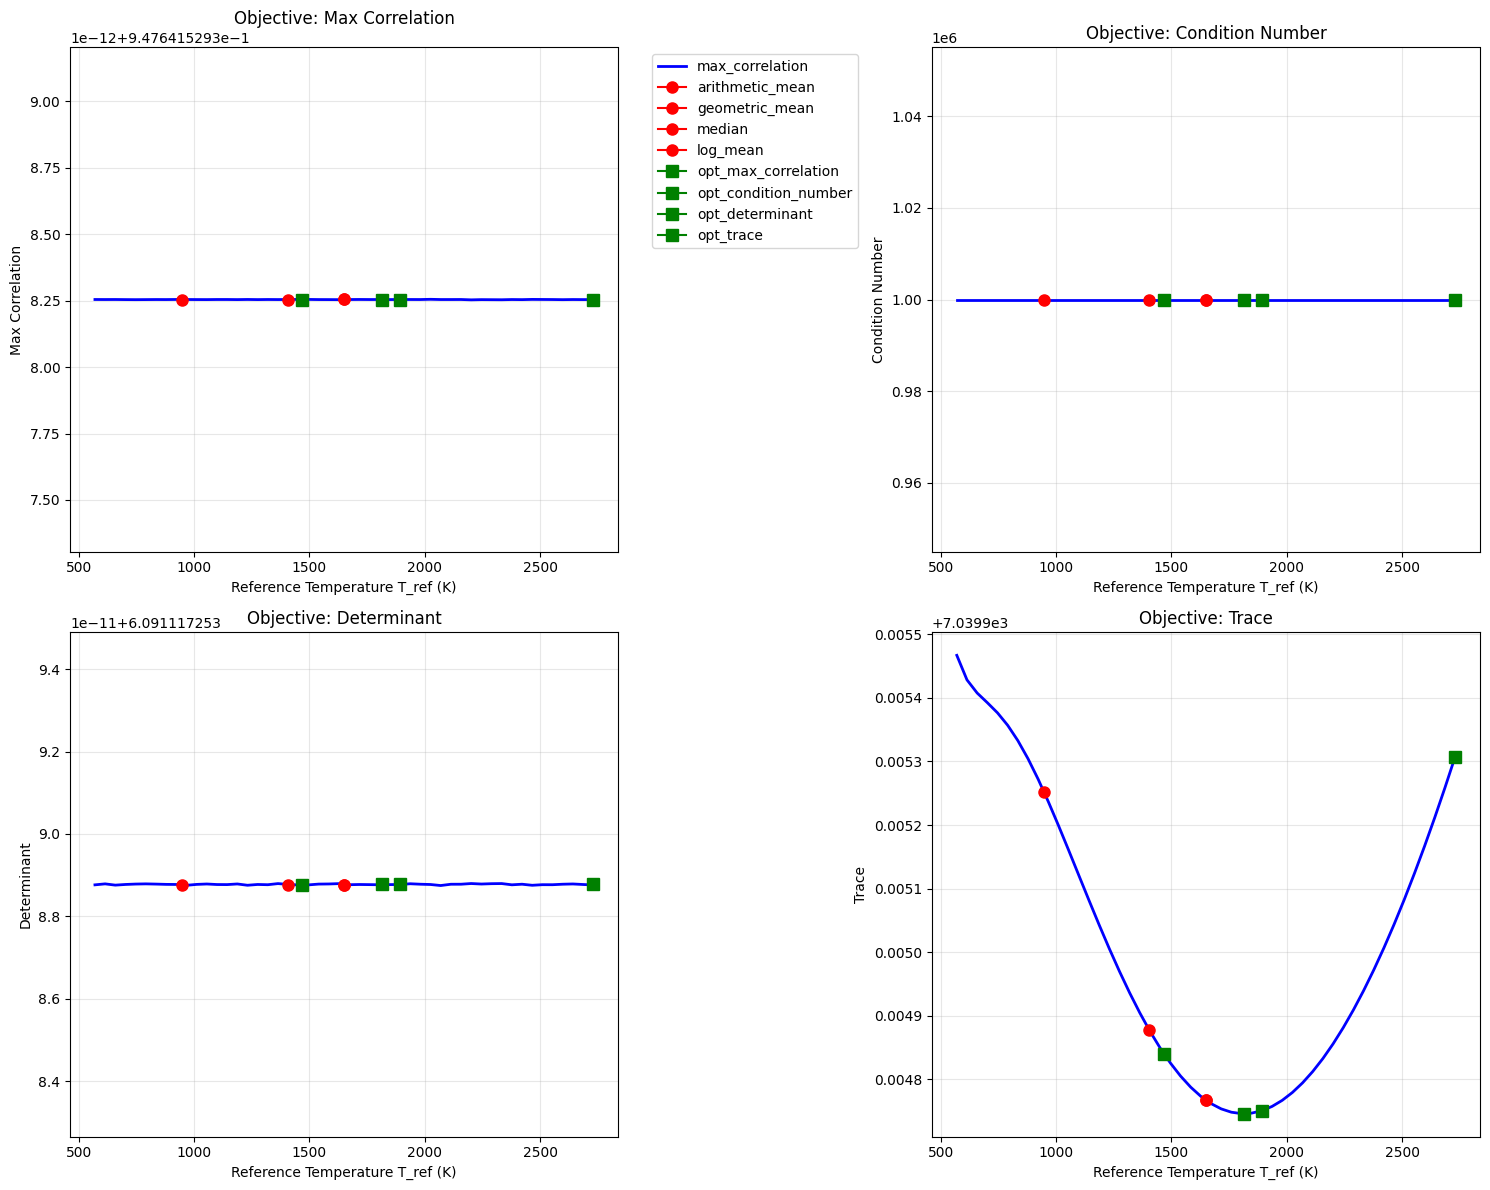


Best heuristic strategy: geometric_mean (max_corr = 0.9476)
Best optimized strategy: opt_max_correlation (max_corr = 0.9476)
Improvement: 0.0% reduction in maximum correlation

DETAILED FITTING COMPARISON:
--------------------------------------------------

ARITHMETIC_MEAN (T_ref = 1650.0 K):
  Parameters: log(k_ref)=29.229, n=1.487, Ea/R=4357.6
  Max correlation: 0.9476
  Condition number: 2.08e+07+0.00e+00j
  Correlations: log(k_ref)-n=-0.337, log(k_ref)-Ea/R=0.432, n-Ea/R=-0.948

BEST_OPTIMIZED (T_ref = 1893.0 K):
  Parameters: log(k_ref)=29.772, n=1.487, Ea/R=4357.6
  Max correlation: 0.9476
  Condition number: 2.27e+07+0.00e+00j
  Correlations: log(k_ref)-n=-0.021, log(k_ref)-Ea/R=0.166, n-Ea/R=-0.948


In [20]:
import jax.numpy as jnp
import jax
import optimistix as optx
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar, minimize

def arrhenius_centered_ea_r(T, k_ref, T_ref, n, Ea_over_R):
    """Centered reparametrization with Ea/R: k = k_ref * (T/T_ref)^n * exp(-Ea_over_R * (1/T - 1/T_ref))"""
    return k_ref * jnp.power(T / T_ref, n) * jnp.exp(-Ea_over_R * (1/T - 1/T_ref))

def residual_fn_centered_ea_r(params, args):
    """Centered Arrhenius with Ea/R: params = [log(k_ref), n, Ea/R]"""
    T_data, k_data, T_ref = args
    log_k_ref = params[0]
    n = params[1]
    Ea_over_R = params[2]
    k_ref = jnp.exp(log_k_ref)
    k_pred = arrhenius_centered_ea_r(T_data, k_ref, T_ref, n, Ea_over_R)
    return jnp.log(k_pred) - jnp.log(k_data)

def compute_parameter_uncertainty_with_noise(sol, residual_variance=None):
    """Compute parameter uncertainties accounting for residual variance."""
    
    # Get the final Jacobian from the solution
    final_jacobian = sol.state.f_info.jac
    
    # Convert to dense matrix
    if hasattr(final_jacobian, 'as_dense'):
        J = final_jacobian.as_dense()
    else:
        # For FunctionLinearOperator, evaluate it properly
        n_params = len(sol.value)
        n_residuals = len(sol.state.f_info.residual)
        
        # Create unit vectors and apply the Jacobian
        J_cols = []
        for i in range(n_params):
            unit_vec = jnp.zeros(n_params)
            unit_vec = unit_vec.at[i].set(1.0)
            col = final_jacobian.mv(unit_vec)
            J_cols.append(col)
        
        J = jnp.column_stack(J_cols)
    
    residuals = sol.state.f_info.residual
    
    # Estimate residual variance if not provided
    if residual_variance is None:
        dof = len(residuals) - len(sol.value)
        if dof > 0:
            residual_variance = jnp.sum(residuals**2) / dof
        else:
            residual_variance = jnp.sum(residuals**2)
    
    # Covariance matrix
    JtJ = J.T @ J
    
    try:
        cov_matrix = residual_variance * jnp.linalg.inv(JtJ)
        std_errors = jnp.sqrt(jnp.diag(cov_matrix))
        return std_errors, cov_matrix, residual_variance
    except jnp.linalg.LinAlgError:
        print("Warning: Covariance matrix is singular")
        return None, None, residual_variance

def objective_function_for_tref_optimization(T_ref, T_data, k_data, objective_type='max_correlation'):
    """
    Objective function for T_ref optimization.
    
    Parameters:
    - T_ref: Reference temperature to optimize
    - T_data: Temperature data
    - k_data: Rate constant data
    - objective_type: 'max_correlation', 'condition_number', 'determinant', or 'trace'
    
    Returns:
    - Objective value to minimize
    """
    
    # Estimate k_ref at T_ref by interpolation
    k_ref_est = jnp.interp(T_ref, T_data, k_data)
    
    # Initial guess for parameters
    initial_guess = jnp.array([jnp.log(k_ref_est), 1.0, 4500.0])
    
    # Solver setup
    solver = optx.LevenbergMarquardt(rtol=1e-10, atol=1e-10)  #, max_steps=1000)
    
    try:
        # Fit parameters
        sol = optx.least_squares(
            fn=residual_fn_centered_ea_r,
            solver=solver,
            y0=initial_guess,
            args=(T_data, k_data, T_ref)
        )
        
        if sol.result != optx.RESULTS.successful:
            return 1e6  # Large penalty for failed optimization
        
        # Compute covariance matrix
        std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol)
        
        if cov_matrix is None:
            return 1e6  # Large penalty for singular covariance
        
        # Compute correlation matrix
        std_matrix = jnp.outer(std_errors, std_errors)
        corr_matrix = cov_matrix / std_matrix
        
        # Different objective functions
        if objective_type == 'max_correlation':
            # Minimize maximum absolute correlation coefficient
            max_corr = jnp.max(jnp.abs(corr_matrix - jnp.eye(3)))
            return float(max_corr)
        
        elif objective_type == 'condition_number':
            # Minimize condition number of covariance matrix
            eigenvals = jnp.linalg.eigvals(cov_matrix)
            condition_number = jnp.max(eigenvals) / jnp.min(eigenvals)
            return float(jnp.log10(condition_number))  # Use log for better scaling
        
        elif objective_type == 'determinant':
            # Maximize determinant of covariance matrix (minimize negative log determinant)
            det_cov = jnp.linalg.det(cov_matrix)
            if det_cov <= 0:
                return 1e6
            return float(-jnp.log(det_cov))
        
        elif objective_type == 'trace':
            # Minimize trace of covariance matrix (sum of variances)
            return float(jnp.trace(cov_matrix))
        
        elif objective_type == 'frobenius_correlation':
            # Minimize Frobenius norm of correlation matrix (excluding diagonal)
            corr_off_diag = corr_matrix - jnp.eye(3)
            return float(jnp.sqrt(jnp.sum(corr_off_diag**2)))
        
        else:
            raise ValueError(f"Unknown objective_type: {objective_type}")
    
    except Exception as e:
        print(f"Error in objective function evaluation at T_ref={T_ref}: {e}")
        return 1e6

def optimize_reference_temperature(T_data, k_data, objective_type='max_correlation', 
                                 method='bounded', bounds_factor=0.8):
    """
    Optimize reference temperature for minimum parameter correlation.
    
    Parameters:
    - T_data: Temperature data array
    - k_data: Rate constant data array
    - objective_type: Optimization objective ('max_correlation', 'condition_number', etc.)
    - method: 'bounded' or 'golden' for optimization method
    - bounds_factor: Fraction of temperature range to search within
    
    Returns:
    - Dictionary with optimization results
    """
    
    T_min, T_max = float(T_data.min()), float(T_data.max())
    T_range = T_max - T_min
    
    # Define search bounds (avoid extremes)
    lower_bound = T_min + (1 - bounds_factor) / 2 * T_range
    upper_bound = T_max - (1 - bounds_factor) / 2 * T_range
    
    print(f"Optimizing T_ref using objective: {objective_type}")
    print(f"Search bounds: [{lower_bound:.1f}, {upper_bound:.1f}] K")
    print(f"Full temperature range: [{T_min:.1f}, {T_max:.1f}] K")
    
    # Wrapper function for scipy optimization
    def objective_wrapper(T_ref):
        return objective_function_for_tref_optimization(T_ref, T_data, k_data, objective_type)
    
    if method == 'bounded':
        # Use bounded optimization
        result = minimize_scalar(
            objective_wrapper,
            bounds=(lower_bound, upper_bound),
            method='bounded',
            options={'xatol': 1e-3}
        )
    else:
        # Use golden section search
        result = minimize_scalar(
            objective_wrapper,
            bounds=(lower_bound, upper_bound),
            method='golden',
            options={'xtol': 1e-3}
        )
    
    optimal_T_ref = result.x
    optimal_objective = result.fun
    
    print(f"Optimal T_ref: {optimal_T_ref:.1f} K")
    print(f"Optimal objective value: {optimal_objective:.6f}")
    
    return {
        'optimal_T_ref': optimal_T_ref,
        'optimal_objective': optimal_objective,
        'optimization_result': result,
        'objective_type': objective_type
    }

def compare_tref_strategies(T_data, k_data, plot_scan=True):
    """
    Compare different T_ref selection strategies.
    
    Parameters:
    - T_data: Temperature data
    - k_data: Rate constant data
    - plot_scan: Whether to plot objective function vs T_ref
    """
    
    strategies = {
        'arithmetic_mean': jnp.mean(T_data),
        'geometric_mean': jnp.sqrt(T_data.min() * T_data.max()),
        'median': jnp.median(T_data),
        'log_mean': jnp.exp(jnp.mean(jnp.log(T_data))),
    }
    
    # Add optimized strategies
    objective_types = ['max_correlation', 'condition_number', 'determinant', 'trace']
    
    results = {}
    
    print("="*80)
    print("COMPARISON OF T_ref SELECTION STRATEGIES")
    print("="*80)
    
    # Evaluate heuristic strategies
    print("\nHEURISTIC STRATEGIES:")
    print("-" * 40)
    
    for name, T_ref in strategies.items():
        T_ref_val = float(T_ref)
        obj_val = objective_function_for_tref_optimization(T_ref_val, T_data, k_data, 'max_correlation')
        results[name] = {
            'T_ref': T_ref_val,
            'max_correlation': obj_val,
            'strategy_type': 'heuristic'
        }
        print(f"{name:15}: T_ref = {T_ref_val:6.1f} K, max_corr = {obj_val:.4f}")
    
    # Evaluate optimized strategies
    print("\nOPTIMIZED STRATEGIES:")
    print("-" * 40)
    
    for obj_type in objective_types:
        opt_result = optimize_reference_temperature(T_data, k_data, obj_type)
        T_ref_opt = opt_result['optimal_T_ref']
        
        # Evaluate all objectives for this T_ref
        max_corr = objective_function_for_tref_optimization(T_ref_opt, T_data, k_data, 'max_correlation')
        cond_num = objective_function_for_tref_optimization(T_ref_opt, T_data, k_data, 'condition_number')
        
        results[f'opt_{obj_type}'] = {
            'T_ref': T_ref_opt,
            'max_correlation': max_corr,
            'condition_number': cond_num,
            'strategy_type': 'optimized',
            'optimization_result': opt_result
        }
        
        print(f"opt_{obj_type:12}: T_ref = {T_ref_opt:6.1f} K, max_corr = {max_corr:.4f}, log_cond = {cond_num:.2f}")
    
    # Plot objective function scan if requested
    if plot_scan:
        plot_objective_scan(T_data, k_data, results)
    
    return results

def plot_objective_scan(T_data, k_data, strategy_results):
    """Plot objective function vs T_ref to visualize optimization landscape."""
    
    T_min, T_max = float(T_data.min()), float(T_data.max())
    T_range = T_max - T_min
    
    # Create T_ref scan range
    T_ref_scan = np.linspace(T_min + 0.1*T_range, T_max - 0.1*T_range, 50)
    
    # Evaluate different objectives
    objectives = ['max_correlation', 'condition_number', 'determinant', 'trace']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, obj_type in enumerate(objectives):
        ax = axes[idx]
        
        # Compute objective values
        obj_values = []
        for T_ref in T_ref_scan:
            try:
                obj_val = objective_function_for_tref_optimization(T_ref, T_data, k_data, obj_type)
                obj_values.append(obj_val)
            except:
                obj_values.append(np.nan)
        
        # Plot objective function
        ax.plot(T_ref_scan, obj_values, 'b-', linewidth=2, label=f'{obj_type}')
        
        # Mark strategy points
        for name, data in strategy_results.items():
            T_ref_val = data['T_ref']
            if T_min <= T_ref_val <= T_max:
                try:
                    obj_val = objective_function_for_tref_optimization(T_ref_val, T_data, k_data, obj_type)
                    
                    if data['strategy_type'] == 'heuristic':
                        marker, color = 'o', 'red'
                    else:
                        marker, color = 's', 'green'
                    
                    ax.plot(T_ref_val, obj_val, marker=marker, color=color, markersize=8, 
                           label=name if idx == 0 else "")
                except:
                    pass
        
        ax.set_xlabel('Reference Temperature T_ref (K)')
        ax.set_ylabel(f'{obj_type.replace("_", " ").title()}')
        ax.set_title(f'Objective: {obj_type.replace("_", " ").title()}')
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

def demonstrate_optimal_tref_fitting(T_data, k_data):
    """Demonstrate fitting with optimal T_ref vs standard choices."""
    
    print("="*80)
    print("DEMONSTRATION: OPTIMAL T_ref vs STANDARD CHOICES")
    print("="*80)
    
    # Compare strategies
    strategy_results = compare_tref_strategies(T_data, k_data, plot_scan=True)
    
    # Select best strategies for detailed comparison
    best_heuristic = min(
        [(name, data) for name, data in strategy_results.items() if data['strategy_type'] == 'heuristic'],
        key=lambda x: x[1]['max_correlation']
    )
    
    best_optimized = min(
        [(name, data) for name, data in strategy_results.items() if data['strategy_type'] == 'optimized'],
        key=lambda x: x[1]['max_correlation']
    )
    
    print(f"\nBest heuristic strategy: {best_heuristic[0]} (max_corr = {best_heuristic[1]['max_correlation']:.4f})")
    print(f"Best optimized strategy: {best_optimized[0]} (max_corr = {best_optimized[1]['max_correlation']:.4f})")
    
    improvement = (best_heuristic[1]['max_correlation'] - best_optimized[1]['max_correlation']) / best_heuristic[1]['max_correlation'] * 100
    print(f"Improvement: {improvement:.1f}% reduction in maximum correlation")
    
    # Detailed fitting comparison
    strategies_to_compare = [
        ('arithmetic_mean', strategy_results['arithmetic_mean']['T_ref']),
        ('best_optimized', best_optimized[1]['T_ref'])
    ]
    
    print(f"\nDETAILED FITTING COMPARISON:")
    print("-" * 50)
    
    for name, T_ref in strategies_to_compare:
        print(f"\n{name.upper()} (T_ref = {T_ref:.1f} K):")
        
        # Fit parameters
        k_ref_est = jnp.interp(T_ref, T_data, k_data)
        initial_guess = jnp.array([jnp.log(k_ref_est), 1.0, 4500.0])
        
        solver = optx.LevenbergMarquardt(rtol=1e-10, atol=1e-10)
        sol = optx.least_squares(
            fn=residual_fn_centered_ea_r,
            solver=solver,
            y0=initial_guess,
            args=(T_data, k_data, T_ref)
        )
        
        if sol.result == optx.RESULTS.successful:
            # Compute uncertainties and correlations
            std_errors, cov_matrix, _ = compute_parameter_uncertainty_with_noise(sol)
            
            if cov_matrix is not None:
                std_matrix = jnp.outer(std_errors, std_errors)
                corr_matrix = cov_matrix / std_matrix
                
                max_corr = jnp.max(jnp.abs(corr_matrix - jnp.eye(3)))
                eigenvals = jnp.linalg.eigvals(cov_matrix)
                condition_number = jnp.max(eigenvals) / jnp.min(eigenvals)
                
                print(f"  Parameters: log(k_ref)={sol.value[0]:.3f}, n={sol.value[1]:.3f}, Ea/R={sol.value[2]:.1f}")
                print(f"  Max correlation: {max_corr:.4f}")
                print(f"  Condition number: {condition_number:.2e}")
                print(f"  Correlations: log(k_ref)-n={corr_matrix[0,1]:.3f}, log(k_ref)-Ea/R={corr_matrix[0,2]:.3f}, n-Ea/R={corr_matrix[1,2]:.3f}")
    
    return strategy_results

# Example usage
if __name__ == "__main__":
    # Mock Arrhenius class for demonstration
    class MockArrhenius:
        def __init__(self, name, parameters):
            self.name = name
            self.A = parameters["A"]
            self.n = parameters["n"] 
            self.Ea = parameters["Ea"]
            
        def rate_constant(self, T):
            R = 1.987
            return self.A * jnp.power(T, self.n) * jnp.exp(-self.Ea / (R * T))
    
    # Generate synthetic data
    reaction_true = MockArrhenius(
        name="O+CH4<=>OH+CH3", 
        parameters={"A": 1.020e9, "n": 1.500, "Ea": 8600.0}
    )
    T = jnp.linspace(300, 3000, 30)
    k_true = reaction_true.rate_constant(T)
    
    # Add noise
    noise_level = 0.1
    key = jax.random.PRNGKey(42)
    noise = jax.random.normal(key, shape=T.shape) * noise_level
    k_noisy = k_true * jnp.exp(noise)
    
    # Demonstrate optimal T_ref selection
    strategy_results = demonstrate_optimal_tref_fitting(T, k_noisy)